# CERN CMS Dielectron :— Notebook 2: Invariant Mass Determination





Determines invariant mass M via three approaches: exact physical formula, PCA-reduced linear regression, and MLP neural network. Includes per-resonance error, confusion matrices, and residual analysis.

In [ ]:
#install if missing
!pip install -q kagglehub shap
try:
    import torch
except ImportError:
    !pip install -q torch


In [ ]:
#libraries setup
import kagglehub, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix,
                             accuracy_score, f1_score)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':12})
np.random.seed(42)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
#device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Running on: {DEVICE}')

 Running on: cuda


In [ ]:
#Data loading
path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')
df = pd.read_csv(os.path.join(path, 'dielectron.csv'))
df.columns = df.columns.str.strip()  # fix trailing spaces
print(f'Shape: {df.shape}')
df.head()

# data cleaning
print(f'Missing values (before drop): {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

df = df.dropna()  # Drop missing values (not just 'M' column)
df = df.drop_duplicates().reset_index(drop=True)

print(f'\nShape after dropping missing values: {df.shape}')
print(f'Missing values (after drop): {df.isnull().sum().sum()}')

# Drop Run and Event (They don't contribute in trainig the model)
df = df.drop(columns=['Run', 'Event'], errors='ignore')

print(f'\nDtypes:\n{df.dtypes.value_counts()}')
df.describe().round(3)

Shape: (100000, 19)
Missing values (before drop): 85
Duplicates: 23

Shape after dropping missing values: (99892, 19)
Missing values (after drop): 0

Dtypes:
float64    15
int64       2
Name: count, dtype: int64


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000,99892.000
mean,36.460,0.136,0.183,-1.512,14.418,-0.064,0.022,-0.005,44.031,-0.003,0.126,-1.590,13.806,-0.073,0.022,-0.004,30.021
std,41.223,13.409,13.475,51.623,12.392,1.463,1.800,1.000,46.763,13.131,13.173,61.458,12.465,1.739,1.817,1.000,25.256
min,0.378,-250.587,-126.079,-840.987,0.220,-4.165,-3.142,-1.000,0.472,-233.730,-145.651,-655.396,0.027,-7.065,-3.142,-1.000,2.000
25%,8.471,-5.237,-5.282,-15.900,3.773,-1.285,-1.527,-1.000,11.070,-4.794,-4.606,-22.062,3.738,-1.893,-1.556,-1.000,12.446
50%,21.740,0.142,0.100,-0.314,12.972,-0.062,0.035,-1.000,25.292,-0.035,0.084,-0.694,11.692,-0.137,0.027,-1.000,21.284
75%,50.064,5.719,5.652,13.232,20.026,1.145,1.563,1.000,66.985,4.820,5.064,19.045,19.602,1.769,1.597,1.000,39.029
max,850.602,134.539,147.467,760.096,265.578,2.623,3.141,1.000,948.375,227.330,166.283,935.558,281.654,3.061,3.141,1.000,109.999


## Physical Validity Checks — Basic Outlier Removal

Before modelling, we enforce **basic physics constraints** to remove events with clearly impossible values:
- **Invariant mass**: $M > 0$ (mass cannot be negative)
- **Energy**: $E_1, E_2 > 0$ (energy cannot be negative)
- **Transverse momentum**: $p_T > 0$ (magnitude is always positive)

We keep these checks minimal to preserve as much data as possible.

Events before physics validation: 99892

Basic physics validation summary:
  Negative mass (M ≤ 0):             0 events
  Negative energy (E ≤ 0):            0 events
  Negative pT (pt ≤ 0):               0 events
  Total removed:                      0 events
  Events after validation:        99892


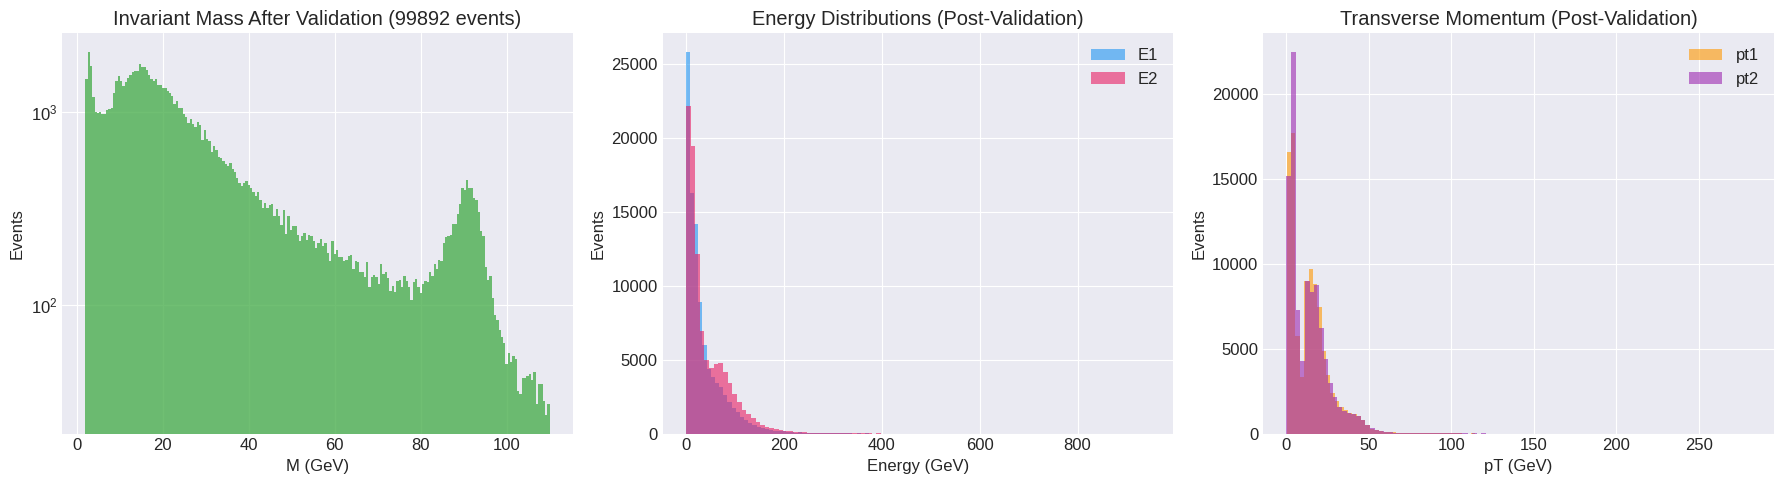

In [ ]:
#Physical Sensors Validity Checks
n_before = len(df)
print(f'Events before physics validation: {n_before}')

# 1.Invariant mass must be positive
mask_M = df['M'] > 0
n_bad_M = (~mask_M).sum()

# 2. Energy must be positive
mask_E = (df['E1'] > 0) & (df['E2'] > 0)
n_bad_E = (~mask_E).sum()

#3. Transverse momentum must be positive
mask_pt = (df['pt1'] > 0) & (df['pt2'] > 0)
n_bad_pt = (~mask_pt).sum()
valid_mask = mask_M & mask_E & mask_pt
df = df[valid_mask].reset_index(drop=True)
n_after = len(df)

print(f'\nBasic physics validation summary:')
print(f'  Negative mass (M ≤ 0):        {n_bad_M:6d} events')
print(f'  Negative energy (E ≤ 0):       {n_bad_E:6d} events')
print(f'  Negative pT (pt ≤ 0):          {n_bad_pt:6d} events')
print(f'  Total removed:                 {n_before - n_after:6d} events')
print(f'  Events after validation:       {n_after:6d}')

# Visualise post-validation distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['M'], bins=200, color='#4CAF50', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('M (GeV)'); axes[0].set_ylabel('Events')
axes[0].set_title(f'Invariant Mass After Validation ({n_after} events)')
axes[0].set_yscale('log')

axes[1].hist(df['E1'], bins=100, color='#2196F3', alpha=0.6, label='E1')
axes[1].hist(df['E2'], bins=100, color='#E91E63', alpha=0.6, label='E2')
axes[1].set_xlabel('Energy (GeV)'); axes[1].set_ylabel('Events')
axes[1].set_title('Energy Distributions (Post-Validation)')
axes[1].legend()

axes[2].hist(df['pt1'], bins=100, color='#FF9800', alpha=0.6, label='pt1')
axes[2].hist(df['pt2'], bins=100, color='#9C27B0', alpha=0.6, label='pt2')
axes[2].set_xlabel('pT (GeV)'); axes[2].set_ylabel('Events')
axes[2].set_title('Transverse Momentum (Post-Validation)')
axes[2].legend()

plt.tight_layout(); plt.show()



## Feature Engineering

We construct **physics-motivated derived features** from the raw sensor measurements.  
These features encode relativistic kinematics relationships between the two electrons and help the ML models capture invariant mass dependencies beyond the raw measured quantities.

### Derived Features

**Pseudorapidity separation**

$$
\Delta\eta = \eta_1 - \eta_2
$$

**Azimuthal angle separation**

$$
\Delta\phi = \phi_1 - \phi_2
$$

**Angular distance in $\eta$-$\phi$ space**

$$
\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2}
$$

**Total transverse momentum**

$$
p_T^{\text{total}} = p_{T_1} + p_{T_2}
$$

**Transverse momentum asymmetry**

$$
A_{p_T} = \frac{p_{T_1} - p_{T_2}}{p_{T_1} + p_{T_2}}
$$

**Total energy of the electron pair**

$$
E_{\text{total}} = E_1 + E_2
$$

**Energy ratio**

$$
R_E = \frac{E_1}{E_2}
$$

**Charge sum**

$$
Q_{\text{sum}} = Q_1 + Q_2
$$

**Collins–Soper angle proxy**

$$
\cos\theta^* = \tanh\left(\frac{\Delta\eta}{2}\right)
$$

These derived variables capture **geometric**, **energy-balance**, and **pairwise kinematic structure**, making them especially useful for improving invariant mass prediction and feature importance analysis.

In [ ]:
#Feature Engineering to add Physics-motivated features
df['delta_eta'] = df['eta1'] - df['eta2']
df['delta_phi'] = df['phi1'] - df['phi2']
df['delta_R']   = np.sqrt(df['delta_eta']**2 + df['delta_phi']**2)
df['pt_total']  = df['pt1'] + df['pt2']
df['pt_asym']   = (df['pt1'] - df['pt2']) / (df['pt1'] + df['pt2'] + 1e-10)
df['E_total']   = df['E1'] + df['E2']
df['E_ratio']   = df['E1'] / (df['E2'] + 1e-10)
df['Q_sum']     = df['Q1'] + df['Q2']
df['cos_theta_star'] = np.tanh(df['delta_eta'] / 2)

print(f'After cleaning: {df.shape}')
print(f'Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star')

After cleaning: (99892, 26)
Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star


For classification evaluation, we bin M into 4 physics-motivated classes:
- **J/ψ region**: 2 ≤ M < 6 GeV
- **Υ region**: 6 ≤ M < 15 GeV  
- **Continuum**: 15 ≤ M < 70 GeV
- **Z boson**: M ≥ 70 GeV

In [ ]:
# Define M ranges for classification
def mass_to_class(m):
    if m < 6:
        return 'J/psi_region'
    elif m < 15:
        return 'Upsilon_region'
    elif m < 70:
        return 'Continuum'
    else:
        return 'Z_boson'

df['label'] = df['M'].apply(mass_to_class)
print('\nClass distribution:')
print(df['label'].value_counts().sort_index())

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(f'\nClasses: {list(le.classes_)}')


Class distribution:
label
Continuum         55993
J/psi_region       9847
Upsilon_region    22910
Z_boson           11142
Name: count, dtype: int64

Classes: ['Continuum', 'J/psi_region', 'Upsilon_region', 'Z_boson']


## Separating Target and Features

In [ ]:
# All sensor/physical property columns (everything except M and derived labels)
feature_cols = [c for c in df.columns if c not in ['M', 'label', 'label_enc']]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].values
y_reg = df['M'].values          # Regression target: continuous M
y_cls = df['label_enc'].values   # Classification target: binned M

#Train/Test Split
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

#Standardization
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train_s.shape}, Test: {X_test_s.shape}')

Feature columns (25): ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'delta_eta', 'delta_phi', 'delta_R', 'pt_total', 'pt_asym', 'E_total', 'E_ratio', 'Q_sum', 'cos_theta_star']

Train: (79913, 25), Test: (19979, 25)


## Model 1: Physical Formula (Baseline)

The **exact** 4-vector invariant mass formula provides a perfect baseline:
$$M = \sqrt{(E_1 + E_2)^2 - (p_{x_1}+p_{x_2})^2 - (p_{y_1}+p_{y_2})^2 - (p_{z_1}+p_{z_2})^2}$$

This uses 8 sensors: E1, px1, py1, pz1, E2, px2, py2, pz2

In [ ]:
#Physical Formula Computation
def compute_invariant_mass(dataframe):
    E_total  = dataframe['E1'] + dataframe['E2']
    px_total = dataframe['px1'] + dataframe['px2']
    py_total = dataframe['py1'] + dataframe['py2']
    pz_total = dataframe['pz1'] + dataframe['pz2']

    M_sq = E_total**2 - px_total**2 - py_total**2 - pz_total**2
    # remove the negative values to 0
    M_computed = np.sqrt(np.maximum(M_sq, 0))
    return M_computed

df['M_formula'] = compute_invariant_mass(df)

# Evaluate formula on test set

_, test_indices, _, _ = train_test_split(
    np.arange(len(df)), y_reg, test_size=0.2, random_state=42
)
test_indices = test_indices.astype(int)

M_formula_test = df['M_formula'].values[test_indices]
M_true_test    = df['M'].values[test_indices]

# Regression metrics for physics formula
rmse_formula = np.sqrt(mean_squared_error(M_true_test, M_formula_test))
mae_formula  = mean_absolute_error(M_true_test, M_formula_test)
r2_formula   = r2_score(M_true_test, M_formula_test)
m_acc_formula = np.mean(np.abs((M_true_test - M_formula_test) / (M_true_test + 1e-10)) < 0.05) * 100

print('Physical Formula — Regression Metrics')
print(f'  RMSE:  {rmse_formula:.6f} GeV')
print(f'  MAE:   {mae_formula:.6f} GeV')
print(f'  R²:    {r2_formula:.6f}')

# Classification
cls_formula_test = np.array([le.transform([mass_to_class(m)])[0] for m in M_formula_test])
f1_formula = f1_score(y_test_cls, cls_formula_test, average='macro')
acc_formula = accuracy_score(y_test_cls, cls_formula_test)

print(f'\n  Regression  (M→pre) Accuracy: {m_acc_formula:.4f}')
print(f'  Classification (M→bin) Accuracy: {acc_formula:.4f}')
print(f'  Classification (M→bin) F1-macro: {f1_formula:.4f}')
print(f'\n  Sensors used: 8 (E1, px1, py1, pz1, E2, px2, py2, pz2)')


Physical Formula — Regression Metrics
  RMSE:  0.002343 GeV
  MAE:   0.000617 GeV
  R²:    1.000000

  Regression  (M→pre) Accuracy: 100.0000
  Classification (M→bin) Accuracy: 1.0000
  Classification (M→bin) F1-macro: 1.0000

  Sensors used: 8 (E1, px1, py1, pz1, E2, px2, py2, pz2)


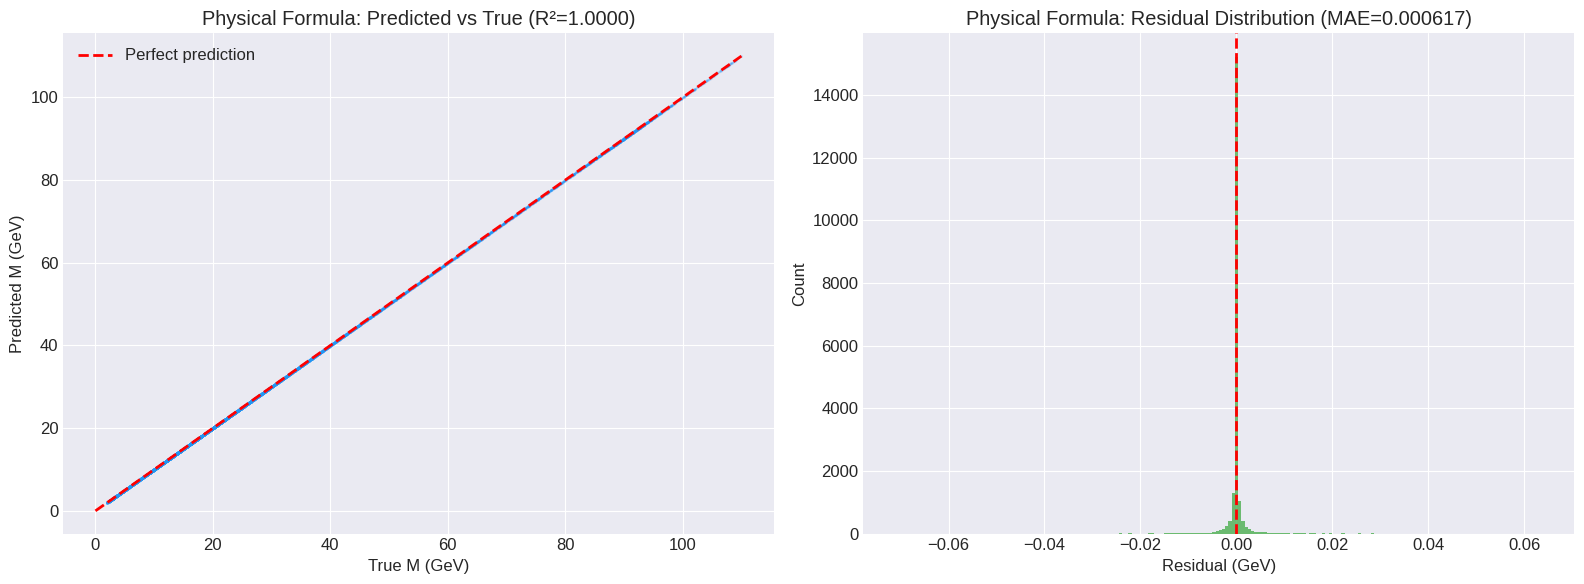

In [ ]:
# Physical Formula: Predicted vs True
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(M_true_test, M_formula_test, alpha=0.1, s=1, color='#2196F3')
axes[0].plot([0, 110], [0, 110], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True M (GeV)'); axes[0].set_ylabel('Predicted M (GeV)')
axes[0].set_title(f'Physical Formula: Predicted vs True (R²={r2_formula:.4f})')
axes[0].legend()

# Residuals
residuals = M_formula_test - M_true_test
axes[1].hist(residuals, bins=200, color='#4CAF50', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Residual (GeV)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Physical Formula: Residual Distribution (MAE={mae_formula:.6f})')
axes[1].axvline(0, color='red', ls='--', lw=2)

plt.tight_layout(); plt.show()

## PCA — Dimensionality Reduction & Feature Selection

We use **Principal Component Analysis** to:
1. Understand the variance structure of our features
2. Select the best reduced features that preserve the most variance
3. Evaluate which components capture the most information about M

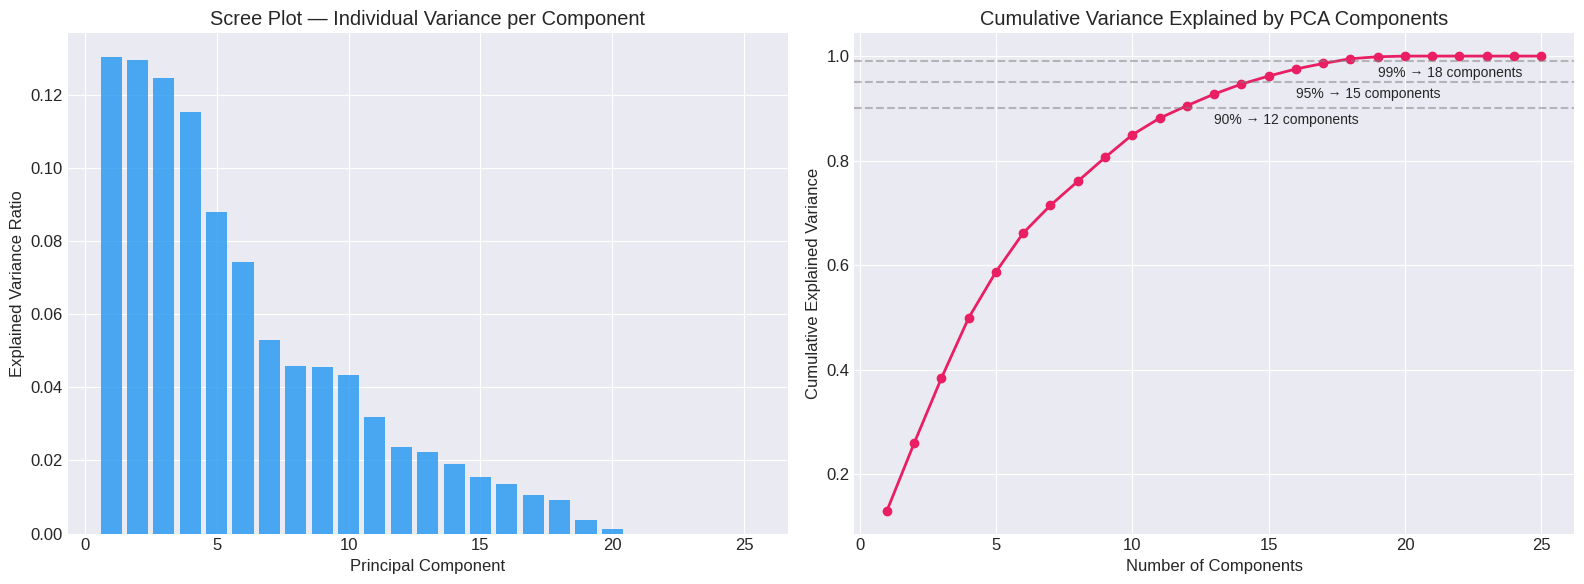


Variance explained by each component:
  PC 1: 13.02%  (cumulative: 13.02%)
  PC 2: 12.95%  (cumulative: 25.97%)
  PC 3: 12.45%  (cumulative: 38.42%)
  PC 4: 11.52%  (cumulative: 49.94%)
  PC 5:  8.79%  (cumulative: 58.73%)
  PC 6:  7.43%  (cumulative: 66.16%)
  PC 7:  5.30%  (cumulative: 71.46%)
  PC 8:  4.58%  (cumulative: 76.04%)
  PC 9:  4.57%  (cumulative: 80.61%)
  PC10:  4.33%  (cumulative: 84.94%)
  PC11:  3.18%  (cumulative: 88.12%)
  PC12:  2.38%  (cumulative: 90.50%)
  PC13:  2.24%  (cumulative: 92.73%)
  PC14:  1.90%  (cumulative: 94.64%)
  PC15:  1.54%  (cumulative: 96.17%)
  PC16:  1.36%  (cumulative: 97.54%)
  PC17:  1.05%  (cumulative: 98.58%)
  PC18:  0.92%  (cumulative: 99.50%)
  PC19:  0.36%  (cumulative: 99.86%)
  PC20:  0.14%  (cumulative: 100.00%)
  PC21:  0.00%  (cumulative: 100.00%)
  PC22:  0.00%  (cumulative: 100.00%)
  PC23:  0.00%  (cumulative: 100.00%)
  PC24:  0.00%  (cumulative: 100.00%)
  PC25:  0.00%  (cumulative: 100.00%)


In [ ]:
# Full PCA to analyse variance
pca_full = PCA()
pca_full.fit(X_train_s)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Individual Variance per Component')

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', color='#E91E63', lw=2)
for thresh in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cumulative_var >= thresh) + 1
    axes[1].axhline(thresh, ls='--', alpha=0.5, color='gray')
    axes[1].annotate(f'{thresh*100:.0f}% → {n_comp} components',
                     xy=(n_comp, thresh), fontsize=10,
                     xytext=(n_comp+1, thresh-0.03))
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained by PCA Components')

plt.tight_layout(); plt.show()

# Print variance explained by each component
print('\nVariance explained by each component:')
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f'  PC{i+1:2d}: {ev:6.2%}  (cumulative: {cv:6.2%})')

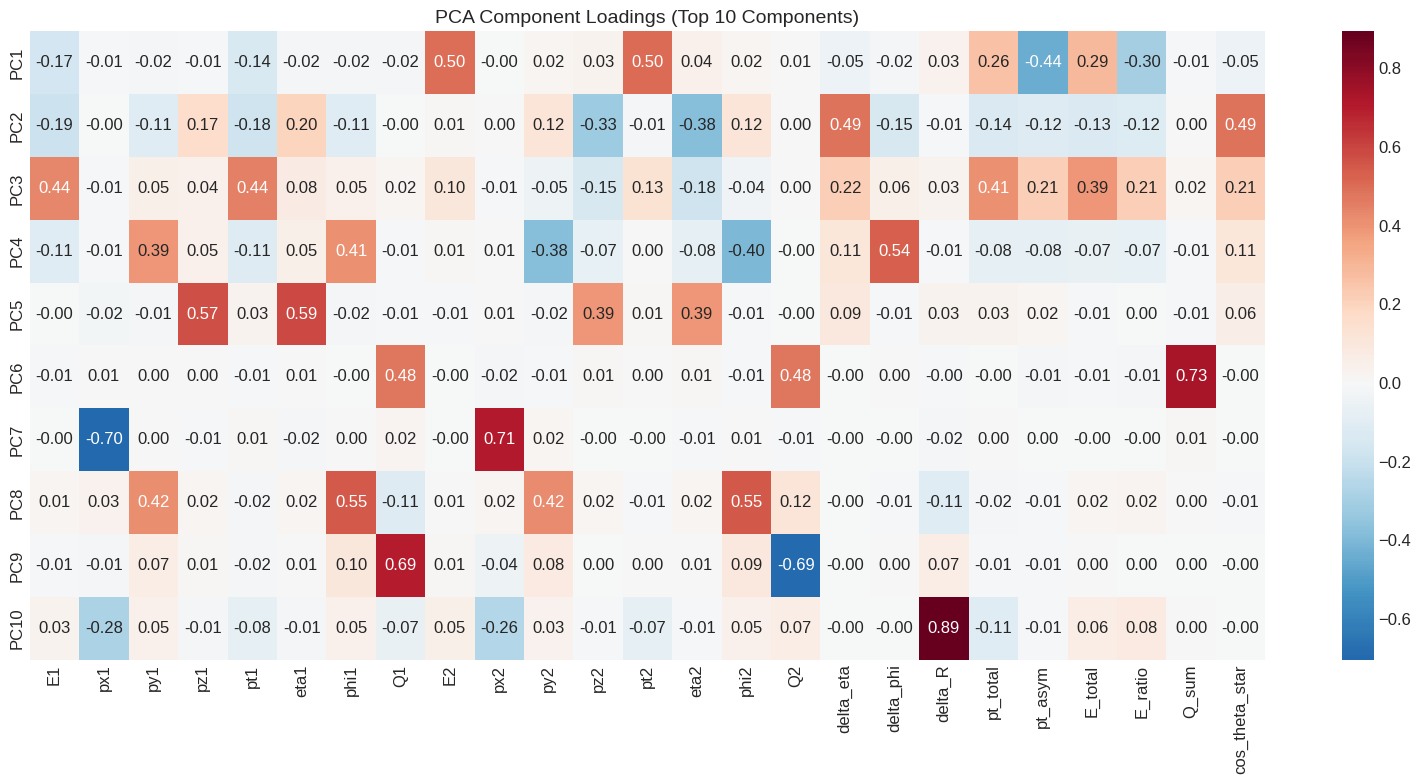

In [ ]:
# PCA component loadings heatmap
n_show = min(10, len(feature_cols))
loadings = pd.DataFrame(
    pca_full.components_[:n_show],
    columns=feature_cols,
    index=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('PCA Component Loadings (Top 10 Components)', fontsize=14)
plt.tight_layout(); plt.show()

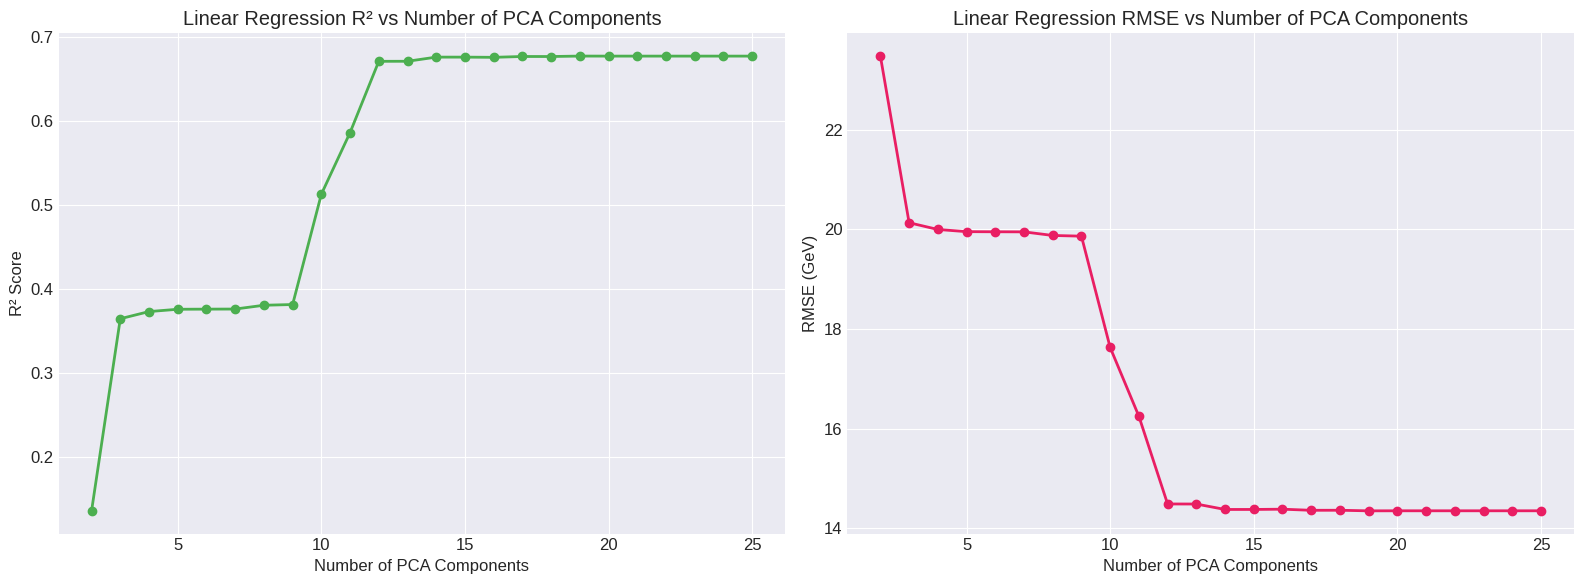


 Best tradeoff: 12 components achieve R² ≥ 0.6429 
   (95% of best R²=0.6768)
   Variance preserved: 0.9050


In [ ]:
# Select optimal number of PCA components We try different numbers of components and evaluate regression quality

component_range = range(2, len(feature_cols)+1)
results_pca = []

for n_comp in component_range:
    pca_temp = PCA(n_components=n_comp)
    X_train_pca = pca_temp.fit_transform(X_train_s)
    X_test_pca  = pca_temp.transform(X_test_s)

    # linear regression
    lr = LinearRegression()
    lr.fit(X_train_pca, y_train_reg)
    y_pred = lr.predict(X_test_pca)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2   = r2_score(y_test_reg, y_pred)
    var_explained = pca_temp.explained_variance_ratio_.sum()

    results_pca.append({
        'n_components': n_comp,
        'variance_explained': var_explained,
        'rmse': rmse,
        'r2': r2
    })

df_pca = pd.DataFrame(results_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_pca['n_components'], df_pca['r2'], 'o-', color='#4CAF50', lw=2)
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Linear Regression R² vs Number of PCA Components')

axes[1].plot(df_pca['n_components'], df_pca['rmse'], 'o-', color='#E91E63', lw=2)
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('RMSE (GeV)')
axes[1].set_title('Linear Regression RMSE vs Number of PCA Components')

plt.tight_layout(); plt.show()

# Find the elbow first N achieving 95% of max R²
max_r2 = df_pca['r2'].max()
threshold = 0.95 * max_r2
best_n = df_pca.loc[df_pca['r2'] >= threshold, 'n_components'].min()
print(f'\n Best tradeoff: {best_n} components achieve R² ≥ {threshold:.4f} ')
print(f'   (95% of best R²={max_r2:.4f})')
print(f'   Variance preserved: {df_pca.loc[df_pca["n_components"]==best_n, "variance_explained"].values[0]:.4f}')

## Model 2: Linear Regression

We predict M directly using linear regression (not logistic — since M is continuous!)  
Then classify by binning the predicted M into the 4 classes.

In [ ]:
# Linear Regression (full features)
lr_full = LinearRegression()
lr_full.fit(X_train_s, y_train_reg)
y_pred_lr_full = lr_full.predict(X_test_s)

rmse_lr_full = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_full))
mae_lr_full  = mean_absolute_error(y_test_reg, y_pred_lr_full)
r2_lr_full   = r2_score(y_test_reg, y_pred_lr_full)

print('Linear Regression (All Features) — Regression Metrics')
print(f'  RMSE:  {rmse_lr_full:.4f} GeV')
print(f'  MAE:   {mae_lr_full:.4f} GeV')
print(f'  R²:    {r2_lr_full:.4f}')

# Classification
cls_lr_full = np.array([le.transform([mass_to_class(max(float(m), 2.0))])[0] for m in y_pred_lr_full])
f1_lr_full = f1_score(y_test_cls, cls_lr_full, average='macro')
acc_lr_full = accuracy_score(y_test_cls, cls_lr_full)

print(f'\n  Classification (M→bin) Accuracy: {acc_lr_full:.4f}')
print(f'  Classification (M→bin) F1-macro: {f1_lr_full:.4f}')
print(f'\n  Sensors used: {len(feature_cols)}')

Linear Regression (All Features) — Regression Metrics
  RMSE:  14.3543 GeV
  MAE:   10.2674 GeV
  R²:    0.6767

  Classification (M→bin) Accuracy: 0.7365
  Classification (M→bin) F1-macro: 0.6451

  Sensors used: 25


In [ ]:
# Linear Regression (PCA-reduced features)
n_pca = best_n
pca_opt = PCA(n_components=n_pca)
X_train_pca = pca_opt.fit_transform(X_train_s)
X_test_pca  = pca_opt.transform(X_test_s)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train_reg)
y_pred_lr_pca = lr_pca.predict(X_test_pca)

rmse_lr_pca = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_pca))
mae_lr_pca  = mean_absolute_error(y_test_reg, y_pred_lr_pca)
r2_lr_pca   = r2_score(y_test_reg, y_pred_lr_pca)

print(f'Linear Regression (PCA {n_pca} Components) — Regression Metrics')
print(f'  RMSE:  {rmse_lr_pca:.4f} GeV')
print(f'  MAE:   {mae_lr_pca:.4f} GeV')
print(f'  R²:    {r2_lr_pca:.4f}')

# Classification
cls_lr_pca = np.array([le.transform([mass_to_class(max(float(m), 2.0))])[0] for m in y_pred_lr_pca])
f1_lr_pca = f1_score(y_test_cls, cls_lr_pca, average='macro')
acc_lr_pca = accuracy_score(y_test_cls, cls_lr_pca)

print(f'\n  Classification (M→bin) Accuracy: {acc_lr_pca:.4f}')
print(f'  Classification (M→bin) F1-macro: {f1_lr_pca:.4f}')
print(f'\n  Variance preserved: {pca_opt.explained_variance_ratio_.sum():.4f}')

Linear Regression (PCA 12 Components) — Regression Metrics
  RMSE:  14.4913 GeV
  MAE:   10.4520 GeV
  R²:    0.6705

  Classification (M→bin) Accuracy: 0.7286
  Classification (M→bin) F1-macro: 0.6344

  Variance preserved: 0.9050


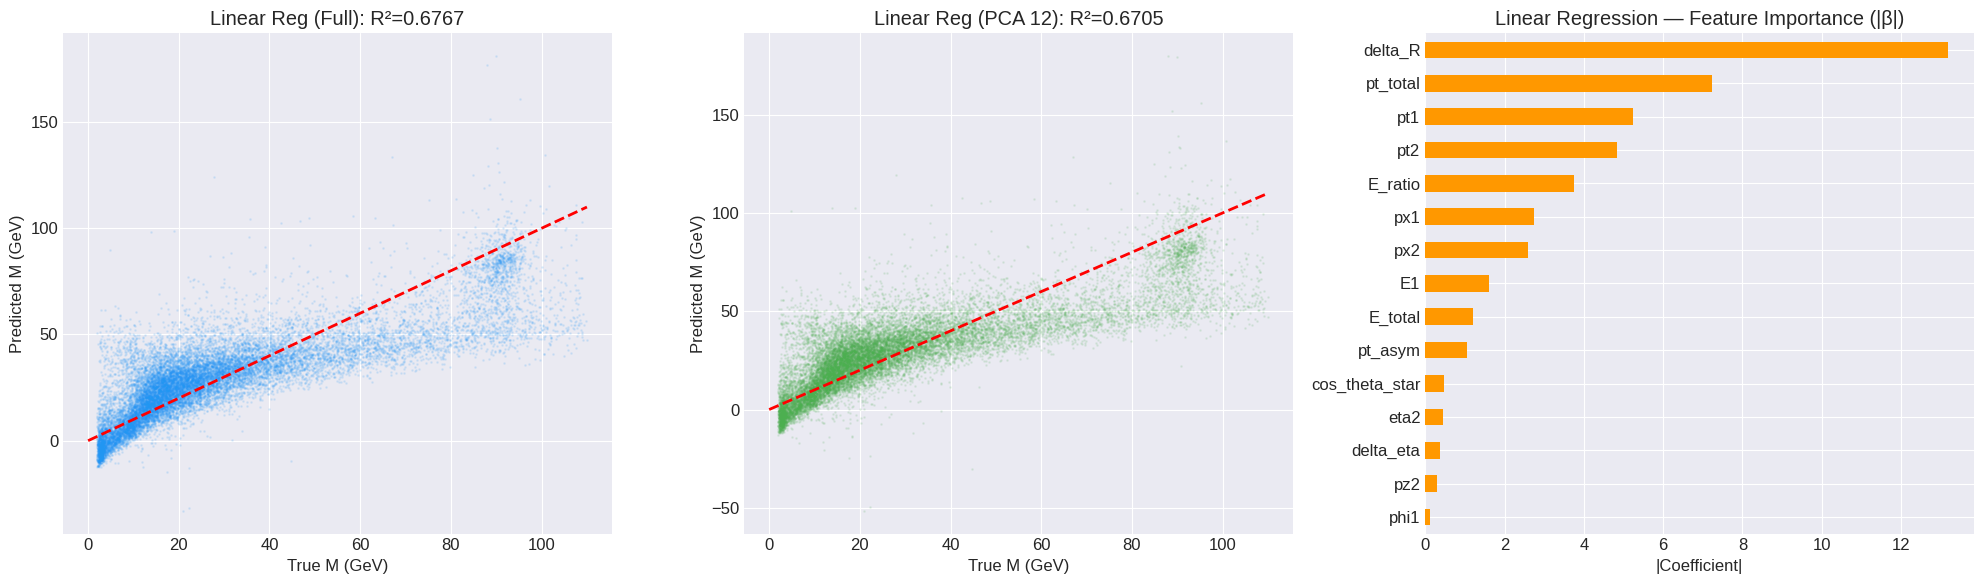

In [ ]:
# Linear Regression Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Predicted vs True (full features)
axes[0].scatter(y_test_reg, y_pred_lr_full, alpha=0.1, s=1, color='#2196F3')
axes[0].plot([0, 110], [0, 110], 'r--', lw=2)
axes[0].set_xlabel('True M (GeV)'); axes[0].set_ylabel('Predicted M (GeV)')
axes[0].set_title(f'Linear Reg (Full): R²={r2_lr_full:.4f}')

# Predicted vs True (PCA)
axes[1].scatter(y_test_reg, y_pred_lr_pca, alpha=0.1, s=1, color='#4CAF50')
axes[1].plot([0, 110], [0, 110], 'r--', lw=2)
axes[1].set_xlabel('True M (GeV)'); axes[1].set_ylabel('Predicted M (GeV)')
axes[1].set_title(f'Linear Reg (PCA {n_pca}): R²={r2_lr_pca:.4f}')

# Feature importance (coefficients magnitude)
coefs = pd.Series(np.abs(lr_full.coef_), index=feature_cols).sort_values(ascending=False)
coefs.head(15).plot(kind='barh', ax=axes[2], color='#FF9800')
axes[2].set_xlabel('|Coefficient|')
axes[2].set_title('Linear Regression — Feature Importance (|β|)')
axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

## Feature Importance :— Permutation Importance

We evaluate feature importance via **permutation importance**: for each feature,
we randomly shuffle its values and measure the increase in RMSE. Features whose
shuffling causes a large RMSE increase are more important.

This is model-agnostic and computationally lightweight (no SHAP needed).


Computing permutation importance on Linear Regression (5 repeats)...


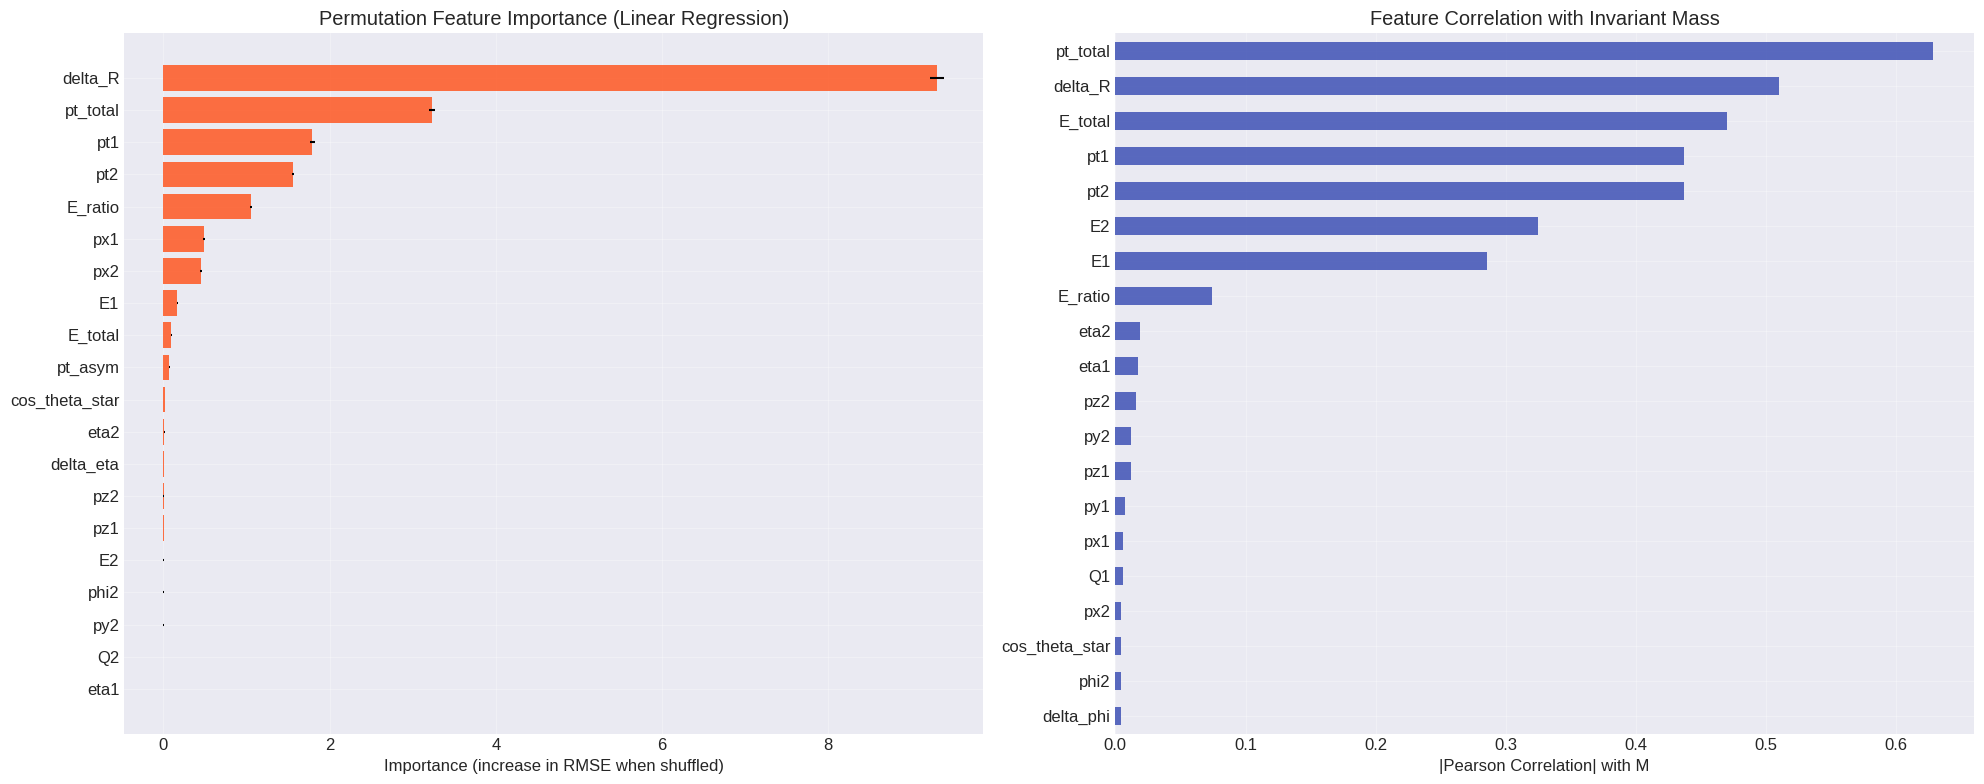


Top 10 most important features (permutation):
 Feature  Importance (ΔRMSE)      Std
 delta_R            9.312526 0.082564
pt_total            3.233305 0.040923
     pt1            1.793627 0.033501
     pt2            1.558750 0.015999
 E_ratio            1.051793 0.011142
     px1            0.488752 0.009090
     px2            0.453995 0.009800
      E1            0.168668 0.010027
 E_total            0.094325 0.006099
 pt_asym            0.067554 0.006391


In [ ]:
# Feature Importance (Permutation-based)
from sklearn.inspection import permutation_importance

# Use the Linear Regression model  for permutation importance
print('Computing permutation importance on Linear Regression (5 repeats)...')
perm_result = permutation_importance(
    lr_full, X_test_s, y_test_reg,
    n_repeats=5, random_state=42,
    scoring='neg_root_mean_squared_error'
)

# Sort by features by importance
perm_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance (ΔRMSE)': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance (ΔRMSE)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#Left: Permutation importance bar chart
top_n = min(20, len(perm_imp))
top_feats = perm_imp.head(top_n)
bars = axes[0].barh(range(top_n), top_feats['Importance (ΔRMSE)'].values,
                     xerr=top_feats['Std'].values,
                     color='#FF5722', alpha=0.85, edgecolor='none')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_feats['Feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance (increase in RMSE when shuffled)')
axes[0].set_title('Permutation Feature Importance (Linear Regression)')
axes[0].grid(True, alpha=0.3)

# Right: Correlation with M
corr_with_M = df[feature_cols].corrwith(df['M']).abs().sort_values(ascending=False)
corr_with_M.head(top_n).plot(kind='barh', ax=axes[1], color='#3F51B5', alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_xlabel('|Pearson Correlation| with M')
axes[1].set_title('Feature Correlation with Invariant Mass')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\nTop 10 most important features (permutation):')
print(perm_imp.head(10).to_string(index=False))


## Model 3: MLP (Neural Network) for Regression

We use a PyTorch MLP to predict M (regression). The MLP can capture
non-linear relationships that linear regression misses.

### Approach
1. **GridSearchCV** — We first perform a cross-validated grid search over
   architectures (hidden sizes, learning rate, dropout) to identify the best
   MLP configuration.
2. **Final Training** — The best architecture is retrained on the full training
   set and evaluated on the held-out test set.
3. **M-Based Accuracy** — Primary metric is relative error on continuous M,
   not class-based accuracy.


In [ ]:

# GPU-accelerated MLP Regressor — PyTorch wrapper

class TorchMLPRegressor:

    def __init__(self, hidden_layer_sizes=(256, 128, 64), activation='relu',
                 lr=1e-3, max_iter=500, batch_size=512,
                 early_stopping=True, patience=20, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.patience = patience
        self.random_state = random_state
        self.device = DEVICE
        self.net = None
        self.loss_curve_ = []

    def _build_net(self, n_features):
        act_fn = nn.ReLU() if self.activation == 'relu' else nn.Tanh()
        layers, in_dim = [], n_features
        for h in self.hidden_layer_sizes:
            layers += [
                nn.Linear(in_dim, h),
                act_fn,
                nn.BatchNorm1d(h),
                nn.Dropout(0.2),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # Single output for regression
        return nn.Sequential(*layers).to(self.device)

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            if self.device.type == 'cuda':
                torch.cuda.manual_seed_all(self.random_state)

        self.net = self._build_net(X.shape[1])
        optimiser = torch.optim.Adam(self.net.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        if self.early_stopping:
            n_val = max(int(0.1 * len(X_t)), 1)
            X_tr, X_val = X_t[:-n_val], X_t[-n_val:]
            y_tr, y_val = y_t[:-n_val], y_t[-n_val:]
        else:
            X_tr, y_tr = X_t, y_t
            X_val, y_val = None, None

        loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=self.batch_size, shuffle=True
        )

        best_val_loss = float('inf')
        patience_count = 0
        self.loss_curve_ = []

        for epoch in range(self.max_iter):
            self.net.train()
            epoch_loss = 0.0
            for Xb, yb in loader:
                Xb, yb = Xb.to(self.device), yb.to(self.device)
                optimiser.zero_grad()
                loss = criterion(self.net(Xb), yb)
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item() * len(Xb)
            epoch_loss /= len(X_tr)
            self.loss_curve_.append(epoch_loss)

            if self.early_stopping:
                self.net.eval()
                with torch.no_grad():
                    val_loss = criterion(
                        self.net(X_val.to(self.device)),
                        y_val.to(self.device)
                    ).item()
                if val_loss < best_val_loss - 1e-4:
                    best_val_loss = val_loss
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= self.patience:
                        print(f'  [TorchMLP] Early stop at epoch {epoch+1}')
                        break
        return self

    def predict(self, X):
        self.net.eval()
        with torch.no_grad():
            preds = self.net(
                torch.tensor(X, dtype=torch.float32).to(self.device)
            )
            return preds.squeeze().cpu().numpy()

print(f'TorchMLPRegressor ready — will train on: {DEVICE}')

TorchMLPRegressor ready — will train on: cuda


### GridSearchCV :— Finding the Best MLP Architecture

We perform K-fold cross-validation over a grid of hyperparameter configurations.
Each config is evaluated using **negative RMSE** on held-out folds, ensuring the
chosen architecture generalises well.


In [ ]:

# GridSearchCV for MLP — Cross-validated architecture selection
class TorchMLPRegressorTunable(TorchMLPRegressor):
    def __init__(self, hidden_layer_sizes=(256,128,64), activation='relu',
                 lr=1e-3, max_iter=300, batch_size=512,
                 early_stopping=True, patience=15, random_state=42, dropout=0.2):
        super().__init__(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                         lr=lr, max_iter=max_iter, batch_size=batch_size,
                         early_stopping=early_stopping, patience=patience,
                         random_state=random_state)
        self.dropout = dropout

    def _build_net(self, n_features):
        act_fn = nn.ReLU() if self.activation == 'relu' else nn.Tanh()
        layers, in_dim = [], n_features
        for h in self.hidden_layer_sizes:
            layers += [nn.Linear(in_dim, h), act_fn, nn.BatchNorm1d(h), nn.Dropout(self.dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        return nn.Sequential(*layers).to(self.device)

#Hyperparameter grid
hp_grid = [
    {'hidden_layer_sizes': (64, 32),         'lr': 1e-3, 'dropout': 0.1},
    {'hidden_layer_sizes': (128, 64),         'lr': 1e-3, 'dropout': 0.1},
    {'hidden_layer_sizes': (128, 64),         'lr': 5e-4, 'dropout': 0.2},
    {'hidden_layer_sizes': (256, 128, 64),    'lr': 1e-3, 'dropout': 0.2},
    {'hidden_layer_sizes': (256, 128, 64),    'lr': 5e-4, 'dropout': 0.2},
    {'hidden_layer_sizes': (256, 128, 64),    'lr': 1e-3, 'dropout': 0.3},
    {'hidden_layer_sizes': (512, 256, 128),   'lr': 1e-3, 'dropout': 0.2},
    {'hidden_layer_sizes': (256, 128),        'lr': 1e-3, 'dropout': 0.1},
]



GridSearchCV: 8 configs × 5-fold CV = 40 fits
  [TorchMLP] Early stop at epoch 56
  [TorchMLP] Early stop at epoch 39
  [TorchMLP] Early stop at epoch 39
  [TorchMLP] Early stop at epoch 37
  [TorchMLP] Early stop at epoch 51
Config 1/8: {'hidden_layer_sizes': (64, 32), 'lr': 0.001, 'dropout': 0.1} → CV RMSE=1.7080±0.0442, M-Acc(5%)=65.0%
  [TorchMLP] Early stop at epoch 56
  [TorchMLP] Early stop at epoch 32
  [TorchMLP] Early stop at epoch 32
  [TorchMLP] Early stop at epoch 53
  [TorchMLP] Early stop at epoch 62
Config 2/8: {'hidden_layer_sizes': (128, 64), 'lr': 0.001, 'dropout': 0.1} → CV RMSE=1.5427±0.2090, M-Acc(5%)=63.3%
  [TorchMLP] Early stop at epoch 63
  [TorchMLP] Early stop at epoch 45
  [TorchMLP] Early stop at epoch 43
  [TorchMLP] Early stop at epoch 56
  [TorchMLP] Early stop at epoch 50
Config 3/8: {'hidden_layer_sizes': (128, 64), 'lr': 0.0005, 'dropout': 0.2} → CV RMSE=1.7450±0.1312, M-Acc(5%)=62.0%
  [TorchMLP] Early stop at epoch 37
  [TorchMLP] Early stop at epo

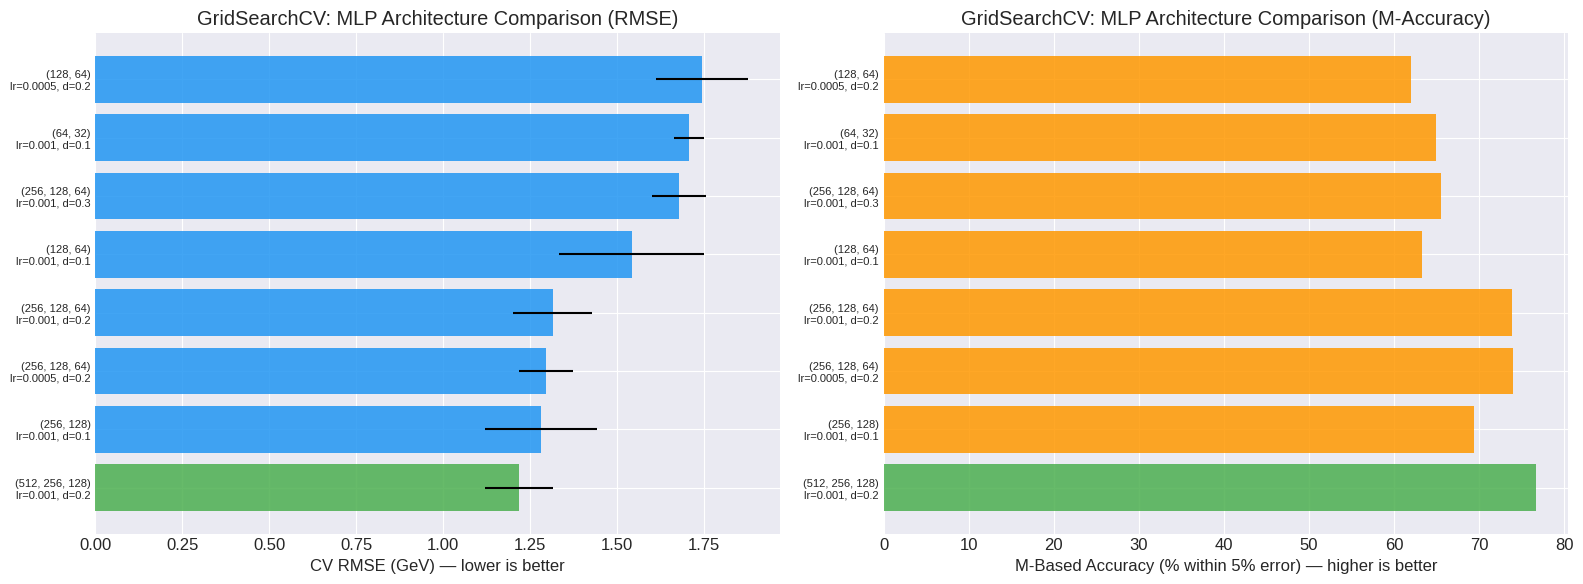

In [ ]:
#Cross-validated evaluation
N_FOLDS = 5  # 5-fold CV
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f'GridSearchCV: {len(hp_grid)} configs × {N_FOLDS}-fold CV = {len(hp_grid)*N_FOLDS} fits')


cv_results = []
for cfg_i, cfg in enumerate(hp_grid):
    fold_rmses = []
    fold_m_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_train_s)):
        X_cv_train = X_train_s[train_idx]
        X_cv_val = X_train_s[val_idx]
        y_cv_train = y_train_reg[train_idx]
        y_cv_val = y_train_reg[val_idx]

        m = TorchMLPRegressorTunable(
            hidden_layer_sizes=cfg['hidden_layer_sizes'],
            lr=cfg['lr'], dropout=cfg['dropout'],
            max_iter=200, batch_size=512,
            early_stopping=True, patience=10
        )
        m.fit(X_cv_train, y_cv_train)
        y_pred_cv = m.predict(X_cv_val)

        rmse_cv = np.sqrt(mean_squared_error(y_cv_val, y_pred_cv))
        # M-based accuracy: fraction within 5% relative error
        rel_err = np.abs((y_cv_val - y_pred_cv) / (y_cv_val + 1e-10))
        m_acc_cv = np.mean(rel_err < 0.05) * 100
        fold_rmses.append(rmse_cv)
        fold_m_accs.append(m_acc_cv)

    mean_rmse = np.mean(fold_rmses)
    std_rmse = np.std(fold_rmses)
    mean_m_acc = np.mean(fold_m_accs)

    cv_results.append({
        'Config': str(cfg['hidden_layer_sizes']),
        'LR': cfg['lr'],
        'Dropout': cfg['dropout'],
        'CV RMSE (mean)': mean_rmse,
        'CV RMSE (std)': std_rmse,
        'CV M-Acc 5% (mean)': mean_m_acc,
        '_cfg': cfg,  # keep for reuse
    })
    print(f'Config {cfg_i+1}/{len(hp_grid)}: {cfg} '
          f'→ CV RMSE={mean_rmse:.4f}±{std_rmse:.4f}, M-Acc(5%)={mean_m_acc:.1f}%')

cv_df = pd.DataFrame(cv_results)
cv_df_display = cv_df.drop(columns=['_cfg'])

print('\n' + '='*80)
print(' GridSearchCV Results ')
print(cv_df_display.sort_values('CV RMSE (mean)').to_string(index=False))

# ── Select best config (lowest CV RMSE) ──
best_idx = cv_df['CV RMSE (mean)'].idxmin()
best_cfg = cv_df.loc[best_idx, '_cfg']
print(f'\nBest MLP config: {best_cfg}')
print(f'   CV RMSE: {cv_df.loc[best_idx, "CV RMSE (mean)"]:.4f} ± {cv_df.loc[best_idx, "CV RMSE (std)"]:.4f}')
print(f'   CV M-Acc(5%): {cv_df.loc[best_idx, "CV M-Acc 5% (mean)"]:.1f}%')

# Visualise grid search results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

configs_str = [f"{r['Config']}\nlr={r['LR']}, d={r['Dropout']}" for _, r in cv_df.iterrows()]
sorted_idx = cv_df['CV RMSE (mean)'].argsort()

# RMSE comparison
axes[0].barh(range(len(cv_df)), cv_df['CV RMSE (mean)'].values[sorted_idx],
             xerr=cv_df['CV RMSE (std)'].values[sorted_idx],
             color=['#4CAF50' if i == best_idx else '#2196F3' for i in sorted_idx],
             alpha=0.85)
axes[0].set_yticks(range(len(cv_df)))
axes[0].set_yticklabels([configs_str[i] for i in sorted_idx], fontsize=8)
axes[0].set_xlabel('CV RMSE (GeV) — lower is better')
axes[0].set_title('GridSearchCV: MLP Architecture Comparison (RMSE)')

# M-Accuracy comparison
axes[1].barh(range(len(cv_df)), cv_df['CV M-Acc 5% (mean)'].values[sorted_idx],
             color=['#4CAF50' if i == best_idx else '#FF9800' for i in sorted_idx],
             alpha=0.85)
axes[1].set_yticks(range(len(cv_df)))
axes[1].set_yticklabels([configs_str[i] for i in sorted_idx], fontsize=8)
axes[1].set_xlabel('M-Based Accuracy (% within 5% error) — higher is better')
axes[1].set_title('GridSearchCV: MLP Architecture Comparison (M-Accuracy)')

plt.tight_layout(); plt.show()


### Final MLP Training :— Best Architecture from GridSearchCV

We retrain the best MLP configuration (selected by cross-validation) on the
full training set and evaluate on the held-out test set.


In [ ]:
# Train best MLP (full features) using GridSearchCV-selected architecture
print(f'Training best MLP config: {best_cfg}')

mlp_full = TorchMLPRegressorTunable(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    lr=best_cfg['lr'], dropout=best_cfg['dropout'],
    max_iter=500, batch_size=512,
    early_stopping=True, patience=20
)
mlp_full.fit(X_train_s, y_train_reg)
y_pred_mlp_full = mlp_full.predict(X_test_s)

# PRIMARY METRIC: M-based accuracy (continuous)
rmse_mlp_full = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlp_full))
mae_mlp_full  = mean_absolute_error(y_test_reg, y_pred_mlp_full)
r2_mlp_full   = r2_score(y_test_reg, y_pred_mlp_full)
rel_err_mlp_full = np.abs((y_test_reg - y_pred_mlp_full) / (y_test_reg + 1e-10))
m_acc_mlp_full = np.mean(rel_err_mlp_full < 0.05) * 100

print(f'\nMLP (Best Config, Full Features) — M-Based Metrics (PRIMARY)')
print(f'  RMSE:              {rmse_mlp_full:.4f} GeV')
print(f'  MAE:               {mae_mlp_full:.4f} GeV')
print(f'  R²:                {r2_mlp_full:.6f}')
print(f'  M-Accuracy (5%):   {m_acc_mlp_full:.2f}%  - PRIMARY METRIC')

# SECONDARY: Classification via predicted M → bin
cls_mlp_full = np.array([le.transform([mass_to_class(max(float(m), 2.0))])[0] for m in y_pred_mlp_full])
f1_mlp_full  = f1_score(y_test_cls, cls_mlp_full, average='macro')
acc_mlp_full = accuracy_score(y_test_cls, cls_mlp_full)

print(f'\n  [Secondary] Classification (M→bin) Accuracy: {acc_mlp_full:.4f}')
print(f'  [Secondary] Classification (M→bin) F1-macro:  {f1_mlp_full:.4f}')


Training best MLP config: {'hidden_layer_sizes': (512, 256, 128), 'lr': 0.001, 'dropout': 0.2}
  [TorchMLP] Early stop at epoch 80

MLP (Best Config, Full Features) — M-Based Metrics (PRIMARY)
  RMSE:              1.1589 GeV
  MAE:               0.7391 GeV
  R²:                0.997893
  M-Accuracy (5%):   78.72%  - PRIMARY METRIC

  [Secondary] Classification (M→bin) Accuracy: 0.9709
  [Secondary] Classification (M→bin) F1-macro:  0.9596


In [ ]:
# Train best MLP (PCA-reduced features)
print(f'Training best MLP config on PCA ({n_pca} components)...')

mlp_pca = TorchMLPRegressorTunable(
    hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
    lr=best_cfg['lr'], dropout=best_cfg['dropout'],
    max_iter=500, batch_size=512,
    early_stopping=True, patience=20
)
mlp_pca.fit(X_train_pca, y_train_reg)
y_pred_mlp_pca = mlp_pca.predict(X_test_pca)

# PRIMARY: M-based metrics
rmse_mlp_pca = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlp_pca))
mae_mlp_pca  = mean_absolute_error(y_test_reg, y_pred_mlp_pca)
r2_mlp_pca   = r2_score(y_test_reg, y_pred_mlp_pca)
rel_err_mlp_pca = np.abs((y_test_reg - y_pred_mlp_pca) / (y_test_reg + 1e-10))
m_acc_mlp_pca = np.mean(rel_err_mlp_pca < 0.05) * 100

print(f'\n MLP (Best Config, PCA {n_pca}) — M-Based Metrics (PRIMARY)')
print(f'  RMSE:              {rmse_mlp_pca:.4f} GeV')
print(f'  MAE:               {mae_mlp_pca:.4f} GeV')
print(f'  R²:                {r2_mlp_pca:.6f}')
print(f'  M-Accuracy (5%):   {m_acc_mlp_pca:.2f}%  ← PRIMARY METRIC')

# SECONDARY: Classification
cls_mlp_pca = np.array([le.transform([mass_to_class(max(float(m), 2.0))])[0] for m in y_pred_mlp_pca])
f1_mlp_pca  = f1_score(y_test_cls, cls_mlp_pca, average='macro')
acc_mlp_pca = accuracy_score(y_test_cls, cls_mlp_pca)

print(f'\n  [Secondary] Classification (M→bin) Accuracy: {acc_mlp_pca:.4f}')
print(f'  [Secondary] Classification (M→bin) F1-macro:  {f1_mlp_pca:.4f}')


Training best MLP config on PCA (12 components)...
  [TorchMLP] Early stop at epoch 96

 MLP (Best Config, PCA 12) — M-Based Metrics (PRIMARY)
  RMSE:              1.7036 GeV
  MAE:               1.3177 GeV
  R²:                0.995447
  M-Accuracy (5%):   57.70%  ← PRIMARY METRIC

  [Secondary] Classification (M→bin) Accuracy: 0.8851
  [Secondary] Classification (M→bin) F1-macro:  0.7809


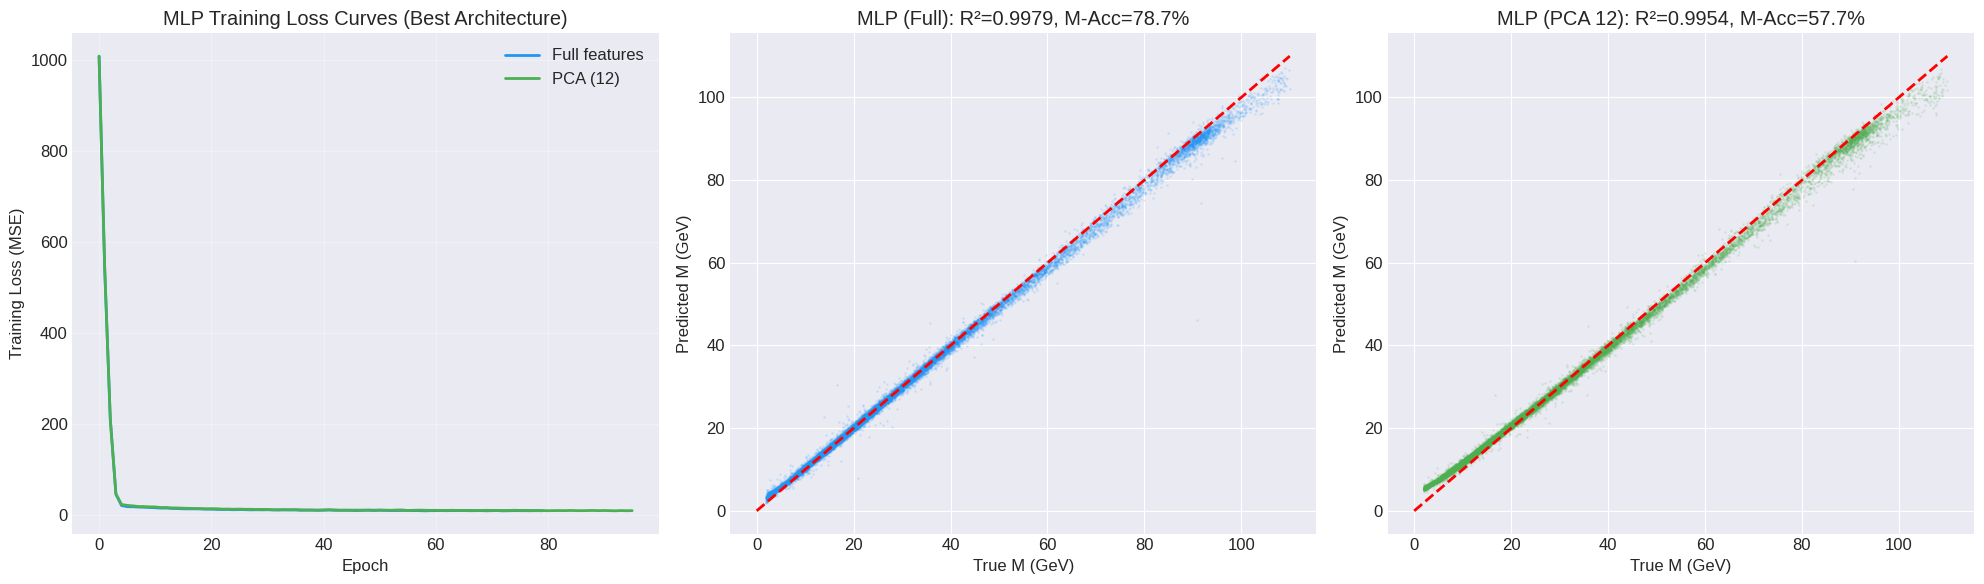

In [ ]:
# MLP Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Loss curves
axes[0].plot(mlp_full.loss_curve_, color='#2196F3', lw=2, label='Full features')
axes[0].plot(mlp_pca.loss_curve_, color='#4CAF50', lw=2, label=f'PCA ({n_pca})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss (MSE)')
axes[0].set_title('MLP Training Loss Curves (Best Architecture)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs True (full)
axes[1].scatter(y_test_reg, y_pred_mlp_full, alpha=0.1, s=1, color='#2196F3')
axes[1].plot([0, 110], [0, 110], 'r--', lw=2)
axes[1].set_xlabel('True M (GeV)'); axes[1].set_ylabel('Predicted M (GeV)')
axes[1].set_title(f'MLP (Full): R²={r2_mlp_full:.4f}, M-Acc={m_acc_mlp_full:.1f}%')

# Predicted vs True (PCA)
axes[2].scatter(y_test_reg, y_pred_mlp_pca, alpha=0.1, s=1, color='#4CAF50')
axes[2].plot([0, 110], [0, 110], 'r--', lw=2)
axes[2].set_xlabel('True M (GeV)'); axes[2].set_ylabel('Predicted M (GeV)')
axes[2].set_title(f'MLP (PCA {n_pca}): R²={r2_mlp_pca:.4f}, M-Acc={m_acc_mlp_pca:.1f}%')

plt.tight_layout(); plt.show()


## Model Comparison Summary

Compare all three approaches: Physical Formula, Linear Regression, MLP.

> **Primary metric**: M-Based Accuracy = fraction of predictions where
> $\left|\frac{M_{\text{pred}} - M_{\text{true}}}{M_{\text{true}}}\right| < 5\%$
>
> Classification accuracy (M→bin) is **secondary** and derived from predicted M values.


In [ ]:
# Model Comparison Table
# PRIMARY: M-based accuracy = f(M_pred (numerical), M_true (numerical))
# SECONDARY: Classification accuracy from binning predicted M

comparison = pd.DataFrame({
    'Model': [
        'Physical Formula (8 sensors)',
        f'Linear Regression (all {len(feature_cols)} features)',
        f'Linear Regression (PCA {n_pca} components)',
        f'MLP [GridSearchCV best] (all {len(feature_cols)} features)',
        f'MLP [GridSearchCV best] (PCA {n_pca} components)'
    ],
    'M-Acc 5% (%)': [m_acc_formula, m_acc_lr_full, m_acc_lr_pca, m_acc_mlp_full, m_acc_mlp_pca],
    'RMSE (GeV)': [rmse_formula, rmse_lr_full, rmse_lr_pca, rmse_mlp_full, rmse_mlp_pca],
    'MAE (GeV)': [mae_formula, mae_lr_full, mae_lr_pca, mae_mlp_full, mae_mlp_pca],
    'R²': [r2_formula, r2_lr_full, r2_lr_pca, r2_mlp_full, r2_mlp_pca],
    '[Sec.] Cls Accuracy': [acc_formula, acc_lr_full, acc_lr_pca, acc_mlp_full, acc_mlp_pca],
    '[Sec.] Cls F1-macro': [f1_formula, f1_lr_full, f1_lr_pca, f1_mlp_full, f1_mlp_pca]
})

print('Complete Model Comparison ')
print('  PRIMARY metric: M-Acc 5% = % of events where |M_pred - M_true|/M_true < 5%')
print('  SECONDARY: Classification accuracy = binned M prediction vs binned M truth\n')
print(comparison.to_string(index=False))


Complete Model Comparison 
  PRIMARY metric: M-Acc 5% = % of events where |M_pred - M_true|/M_true < 5%
  SECONDARY: Classification accuracy = binned M prediction vs binned M truth

                                      Model  M-Acc 5% (%)  RMSE (GeV)  MAE (GeV)       R²  [Sec.] Cls Accuracy  [Sec.] Cls F1-macro
               Physical Formula (8 sensors)    100.000000    0.002343   0.000617 1.000000             1.000000             1.000000
        Linear Regression (all 25 features)      8.553982   14.354342  10.267360 0.676737             0.736523             0.645101
      Linear Regression (PCA 12 components)      8.258672   14.491306  10.451971 0.670538             0.728615             0.634353
  MLP [GridSearchCV best] (all 25 features)     78.722659    1.158891   0.739121 0.997893             0.970919             0.959601
MLP [GridSearchCV best] (PCA 12 components)     57.700586    1.703557   1.317720 0.995447             0.885129             0.780928


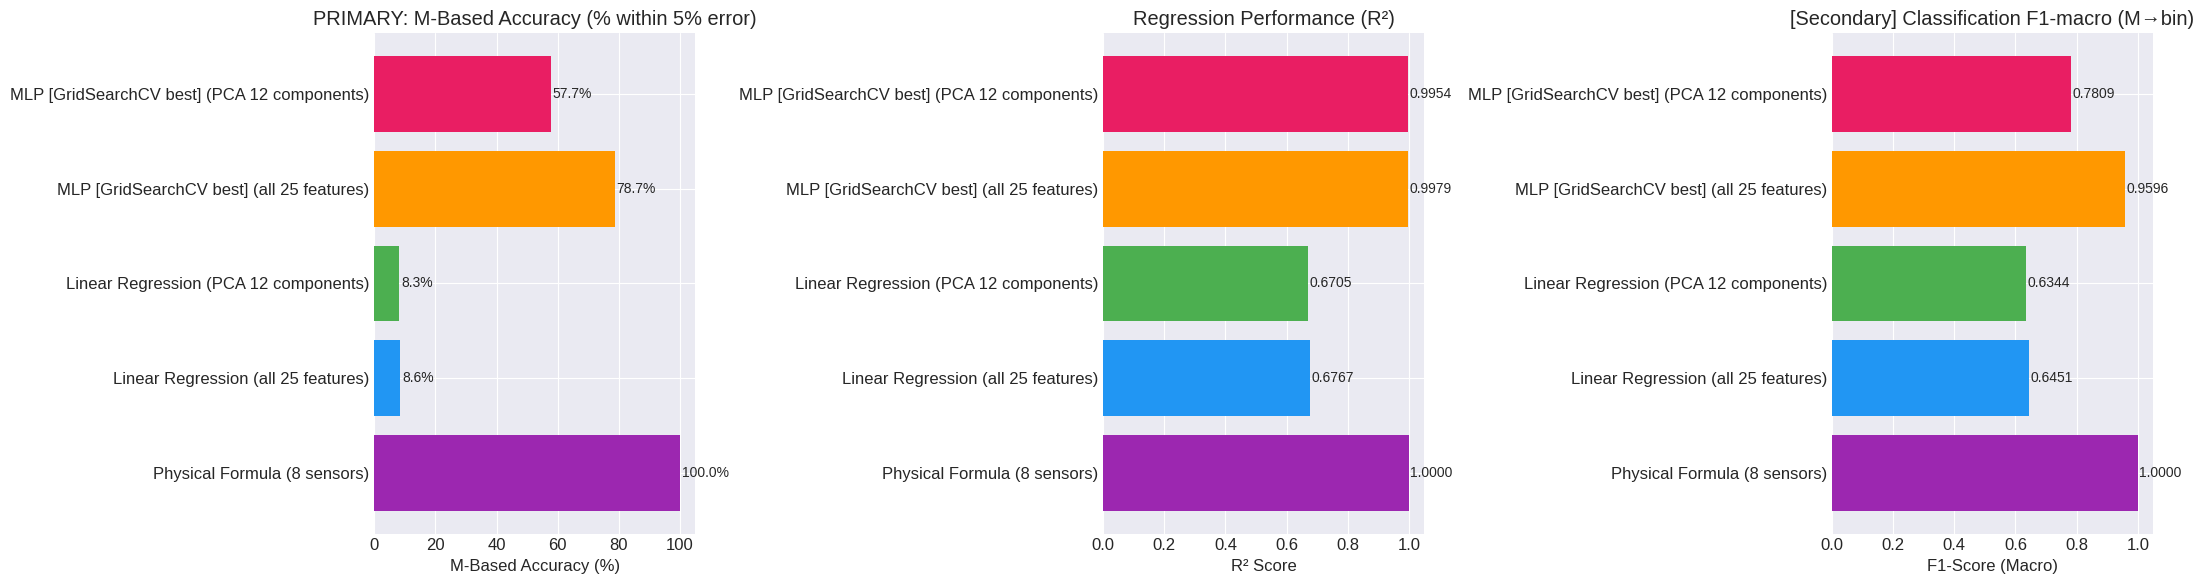

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

models = comparison['Model'].values
colors = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# M-Based Accuracy (PRIMARY)
m_acc_vals = comparison['M-Acc 5% (%)'].values
bars0 = axes[0].barh(models, m_acc_vals, color=colors)
axes[0].set_xlabel('M-Based Accuracy (%)')
axes[0].set_title('PRIMARY: M-Based Accuracy (% within 5% error)')
for b, v in zip(bars0, m_acc_vals):
    axes[0].text(v + 0.5, b.get_y() + b.get_height()/2, f'{v:.1f}%',
                va='center', fontsize=10)

# R² comparison
r2_vals = comparison['R²'].values
bars1 = axes[1].barh(models, r2_vals, color=colors)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Regression Performance (R²)')
for b, v in zip(bars1, r2_vals):
    axes[1].text(v + 0.005, b.get_y() + b.get_height()/2, f'{v:.4f}',
                va='center', fontsize=10)

# Secondary: Classification F1
f1_vals = comparison['[Sec.] Cls F1-macro'].values
bars2 = axes[2].barh(models, f1_vals, color=colors)
axes[2].set_xlabel('F1-Score (Macro)')
axes[2].set_title('[Secondary] Classification F1-macro (M→bin)')
for b, v in zip(bars2, f1_vals):
    axes[2].text(v + 0.005, b.get_y() + b.get_height()/2, f'{v:.4f}',
                va='center', fontsize=10)

plt.tight_layout(); plt.show()


### Per-Resonance Error Analysis

Global R² hides performance differences across resonance regions.
We break down RMSE and MAE per class to find where the model struggles.

Per-Resonance Error Analysis

Physical Formula
  Class                |      N |     RMSE |      MAE |       R²
  ------------------------------------------------------------
  Continuum            |  11232 |   0.0011 |   0.0004 |   1.0000
  J/psi_region         |   1946 |   0.0063 |   0.0021 |   1.0000
  Upsilon_region       |   4587 |   0.0020 |   0.0006 |   1.0000
  Z_boson              |   2214 |   0.0007 |   0.0004 |   1.0000

Linear Regression
  Class                |      N |     RMSE |      MAE |       R²
  ------------------------------------------------------------
  Continuum            |  11232 |  11.8176 |   8.9881 |   0.2702
  J/psi_region         |   1946 |  11.6011 |   8.1433 | -107.5337
  Upsilon_region       |   4587 |  11.9883 |   8.3390 | -21.6227
  Z_boson              |   2214 |  27.1073 |  22.6195 |  -8.5834

MLP
  Class                |      N |     RMSE |      MAE |       R²
  ------------------------------------------------------------
  Continuum            |

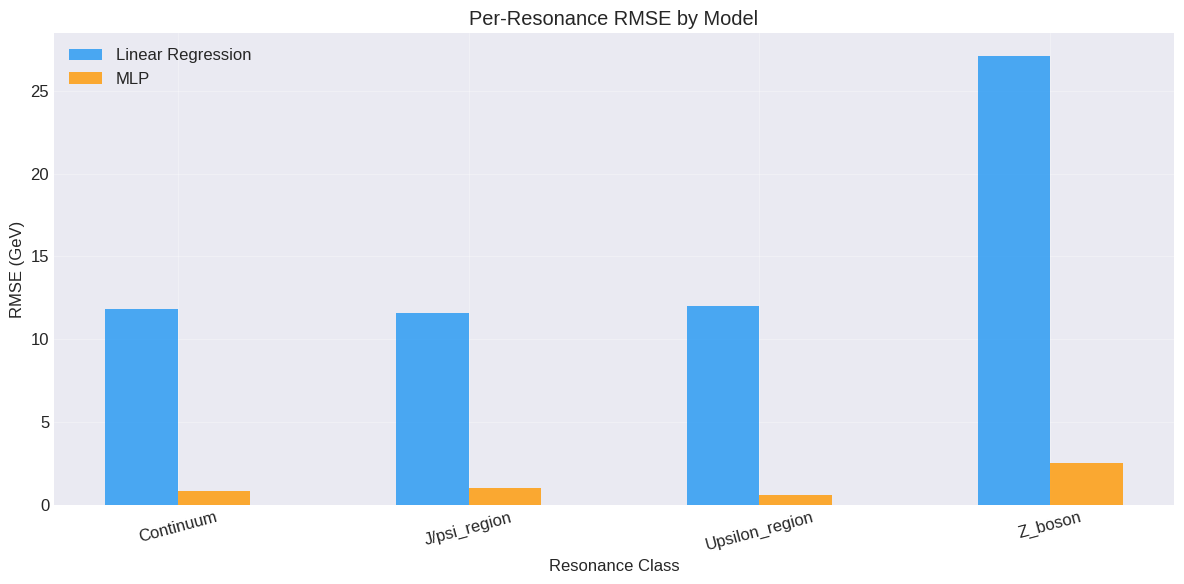

In [ ]:
#Per-resonance error breakdown
models_eval = {
    'Physical Formula': M_formula_test,
    'Linear Regression': y_pred_lr_full,
    'MLP': y_pred_mlp_full,
}

class_names = list(le.classes_)
class_labels = le.transform(class_names)

print('Per-Resonance Error Analysis')
per_res_data = {}

for model_name, y_pred in models_eval.items():
    print(f'\n{model_name}')
    print(f'  {"Class":20s} | {"N":>6s} | {"RMSE":>8s} | {"MAE":>8s} | {"R²":>8s}')
    print('  ' + '-' * 60)
    per_res_data[model_name] = {}
    for cls_name, cls_label in zip(class_names, class_labels):
        mask = y_test_cls == cls_label
        if mask.sum() == 0:
            continue
        y_true_c = y_test_reg[mask]
        y_pred_c = y_pred[mask] if isinstance(y_pred, np.ndarray) else np.array(y_pred)[mask]
        rmse_c = np.sqrt(mean_squared_error(y_true_c, y_pred_c))
        mae_c  = mean_absolute_error(y_true_c, y_pred_c)
        r2_c   = r2_score(y_true_c, y_pred_c) if len(y_true_c) > 1 else float('nan')
        print(f'  {cls_name:20s} | {mask.sum():6d} | {rmse_c:8.4f} | {mae_c:8.4f} | {r2_c:8.4f}')
        per_res_data[model_name][cls_name] = {'rmse': rmse_c, 'mae': mae_c, 'n': int(mask.sum())}

# Visualise per-class RMSE
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25
for i, (mname, col) in enumerate(zip(['Linear Regression', 'MLP'], ['#2196F3', '#FF9800'])):
    rmses = [per_res_data[mname].get(c, {}).get('rmse', 0) for c in class_names]
    ax.bar(x + i*width, rmses, width, label=mname, color=col, alpha=0.8)
ax.set_xlabel('Resonance Class'); ax.set_ylabel('RMSE (GeV)')
ax.set_title('Per-Resonance RMSE by Model')
ax.set_xticks(x + width/2); ax.set_xticklabels(class_names, rotation=15)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Confusion Matrix — MLP Classification

Shows which resonance regions get confused with each other (boundary effects).

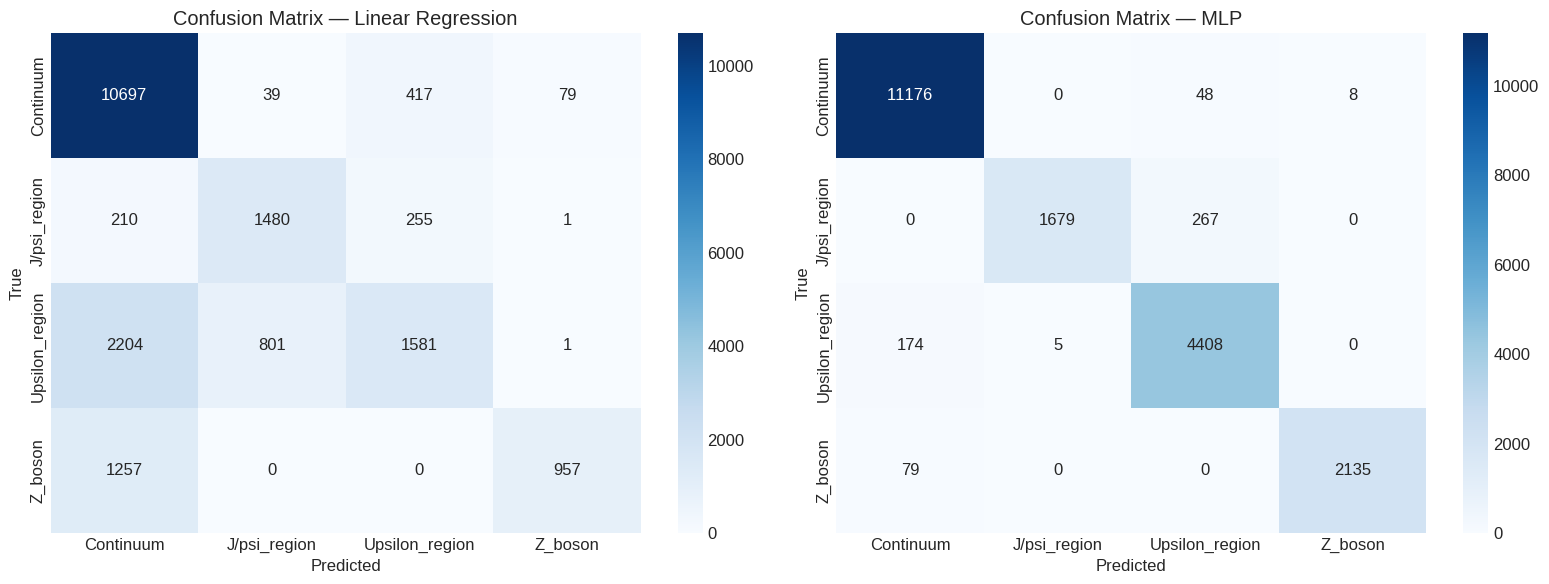


 MLP Classification Report (M→bin) 
                precision    recall  f1-score   support

     Continuum       0.98      1.00      0.99     11232
  J/psi_region       1.00      0.86      0.93      1946
Upsilon_region       0.93      0.96      0.95      4587
       Z_boson       1.00      0.96      0.98      2214

      accuracy                           0.97     19979
     macro avg       0.98      0.95      0.96     19979
  weighted avg       0.97      0.97      0.97     19979



In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred_cls) in zip(axes, [
    ('Linear Regression', cls_lr_full),
    ('MLP', cls_mlp_full)
]):
    cm = confusion_matrix(y_test_cls, y_pred_cls)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout(); plt.show()

# Print classification report for MLP
print('\n MLP Classification Report (M→bin) ')
print(classification_report(y_test_cls, cls_mlp_full, target_names=class_names))

### Residual Analysis by Mass Range

Plotting residuals as a function of true M reveals systematic biases
near resonance peaks — a physically interesting finding related to detector resolution.

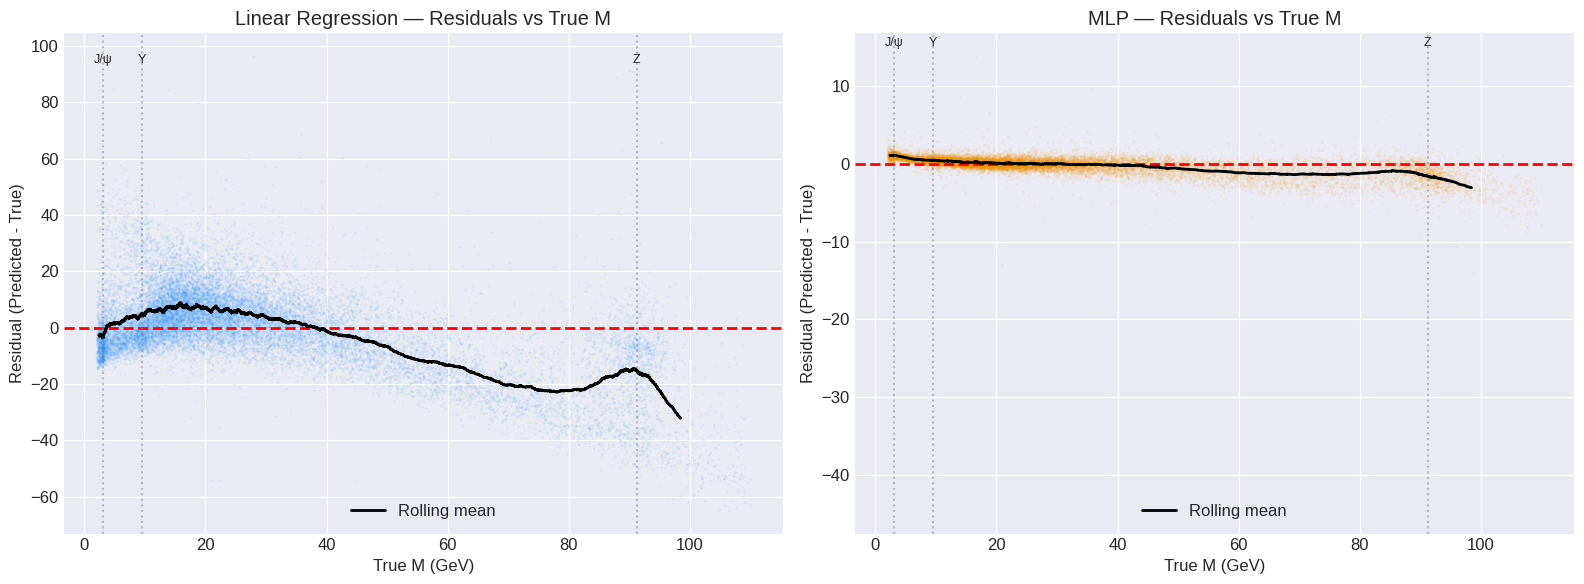

In [ ]:
# Residuals vs True M
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred, color) in zip(axes, [
    ('Linear Regression', y_pred_lr_full, '#2196F3'),
    ('MLP', y_pred_mlp_full, '#FF9800')
]):
    residuals = y_pred - y_test_reg
    ax.scatter(y_test_reg, residuals, alpha=0.05, s=1, color=color)
    ax.axhline(0, color='red', ls='--', lw=2)

    # Mark resonance peaks
    for m, lbl in [(3.1, 'J/ψ'), (9.46, 'Υ'), (91.2, 'Z')]:
        ax.axvline(m, color='gray', ls=':', alpha=0.5)
        ax.text(m, ax.get_ylim()[1]*0.9, lbl, fontsize=9, ha='center')

    # Rolling mean of residuals to show bias
    sort_idx = np.argsort(y_test_reg)
    y_sorted = y_test_reg[sort_idx]
    r_sorted = residuals[sort_idx]
    window = len(y_sorted) // 50
    if window > 1:
        r_rolling = pd.Series(r_sorted).rolling(window, center=True).mean()
        ax.plot(y_sorted, r_rolling, color='black', lw=2, label='Rolling mean')
        ax.legend()

    ax.set_xlabel('True M (GeV)'); ax.set_ylabel('Residual (Predicted - True)')
    ax.set_title(f'{name} — Residuals vs True M')

plt.tight_layout(); plt.show()

## Primary Metric: M-Based Accuracy

All model quality is evaluated on **how well they predict the continuous invariant mass M**.  
Classification accuracy (M→bin) is a secondary, derived metric.

| Metric | What it measures |
|--------|------------------|
| **RMSE** | Root mean squared error on M (penalises large errors) |
| **MAE** | Mean absolute error on M (robust to outliers) |
| **MAPE** | Mean absolute percentage error on M |
| **R²** | Fraction of variance in M explained by the model |
| **Max Error** | Worst-case single-event error |

═══ M-Based Accuracy Summary (PRIMARY EVALUATION) ═══
                     Model  RMSE (GeV)  MAE (GeV)  MAPE (%)       R²  Max Error (GeV)  Within 1 GeV (%)  Within 5 GeV (%)  Within 10 GeV (%)
          Physical Formula    0.002343   0.000617  0.008678 1.000000         0.071008        100.000000        100.000000         100.000000
  Linear Regression (Full)   14.354342  10.267360 63.167261 0.676737        96.370826          7.452825         36.328145          63.661845
Linear Regression (PCA 12)   14.491306  10.451971 63.795995 0.670538        96.462118          7.302668         35.297062          62.205316
                MLP (Full)    1.158891   0.739121  5.294867 0.997893        44.650716         78.207117         99.524501          99.969968
              MLP (PCA 12)    1.703557   1.317720 14.164008 0.995447        30.356580         46.874218         99.159117          99.959958


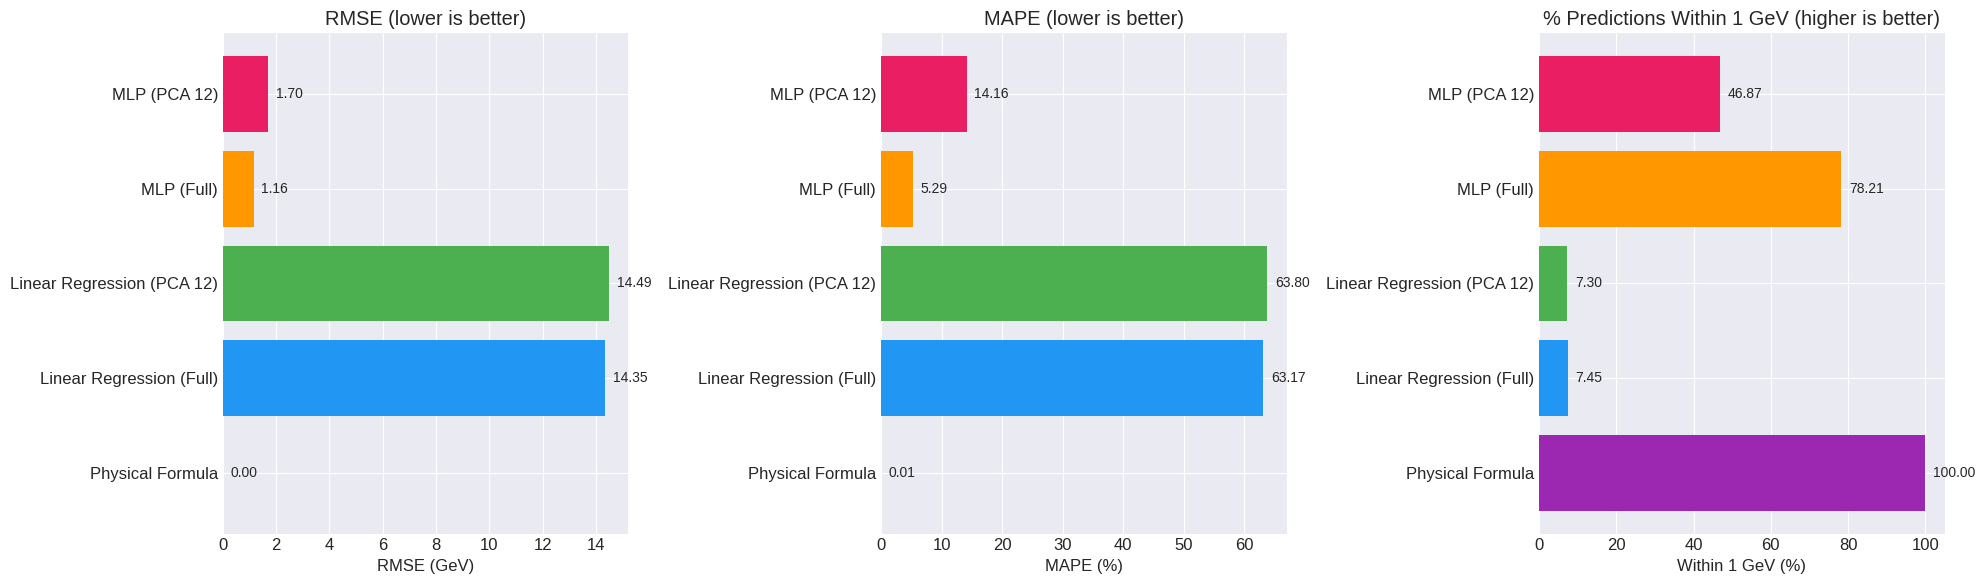

In [ ]:
# Primary Metric: M-Based Accuracy
from sklearn.metrics import max_error

def m_accuracy_report(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    # MAPE: avoid division by zero for very small M
    mask = y_true > 0.1  # skip near-zero mass events
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    maxe = np.max(np.abs(y_true - y_pred))
    # Fraction within 1 GeV, 5 GeV, 10 GeV
    within_1  = np.mean(np.abs(y_true - y_pred) < 1.0)  * 100
    within_5  = np.mean(np.abs(y_true - y_pred) < 5.0)  * 100
    within_10 = np.mean(np.abs(y_true - y_pred) < 10.0) * 100
    return {
        'Model': name, 'RMSE (GeV)': rmse, 'MAE (GeV)': mae,
        'MAPE (%)': mape, 'R²': r2, 'Max Error (GeV)': maxe,
        'Within 1 GeV (%)': within_1, 'Within 5 GeV (%)': within_5,
        'Within 10 GeV (%)': within_10
    }

m_reports = [
    m_accuracy_report('Physical Formula', M_true_test, M_formula_test),
    m_accuracy_report('Linear Regression (Full)', y_test_reg, y_pred_lr_full),
    m_accuracy_report(f'Linear Regression (PCA {n_pca})', y_test_reg, y_pred_lr_pca),
    m_accuracy_report('MLP (Full)', y_test_reg, y_pred_mlp_full),
    m_accuracy_report(f'MLP (PCA {n_pca})', y_test_reg, y_pred_mlp_pca),
]

m_df = pd.DataFrame(m_reports)
print('═══ M-Based Accuracy Summary (PRIMARY EVALUATION) ═══')
print(m_df.to_string(index=False))

# Bar chart of key M-based metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#9C27B0', '#2196F3', '#4CAF50', '#FF9800', '#E91E63']
models_list = m_df['Model'].values

for ax, metric, title in zip(axes,
    ['RMSE (GeV)', 'MAPE (%)', 'Within 1 GeV (%)'],
    ['RMSE (lower is better)', 'MAPE (lower is better)', '% Predictions Within 1 GeV (higher is better)']):
    bars = ax.barh(models_list, m_df[metric].values, color=colors)
    ax.set_xlabel(metric); ax.set_title(title)
    for b, v in zip(bars, m_df[metric].values):
        ax.text(v + max(m_df[metric].values)*0.02, b.get_y() + b.get_height()/2,
                f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout(); plt.show()


## True M vs Model Predictions — Overlay Scatter Plot

Scatter the **true M** for all test events (sorted), then overlay each model's predictions.  
A perfect model would produce points exactly on the true M curve.

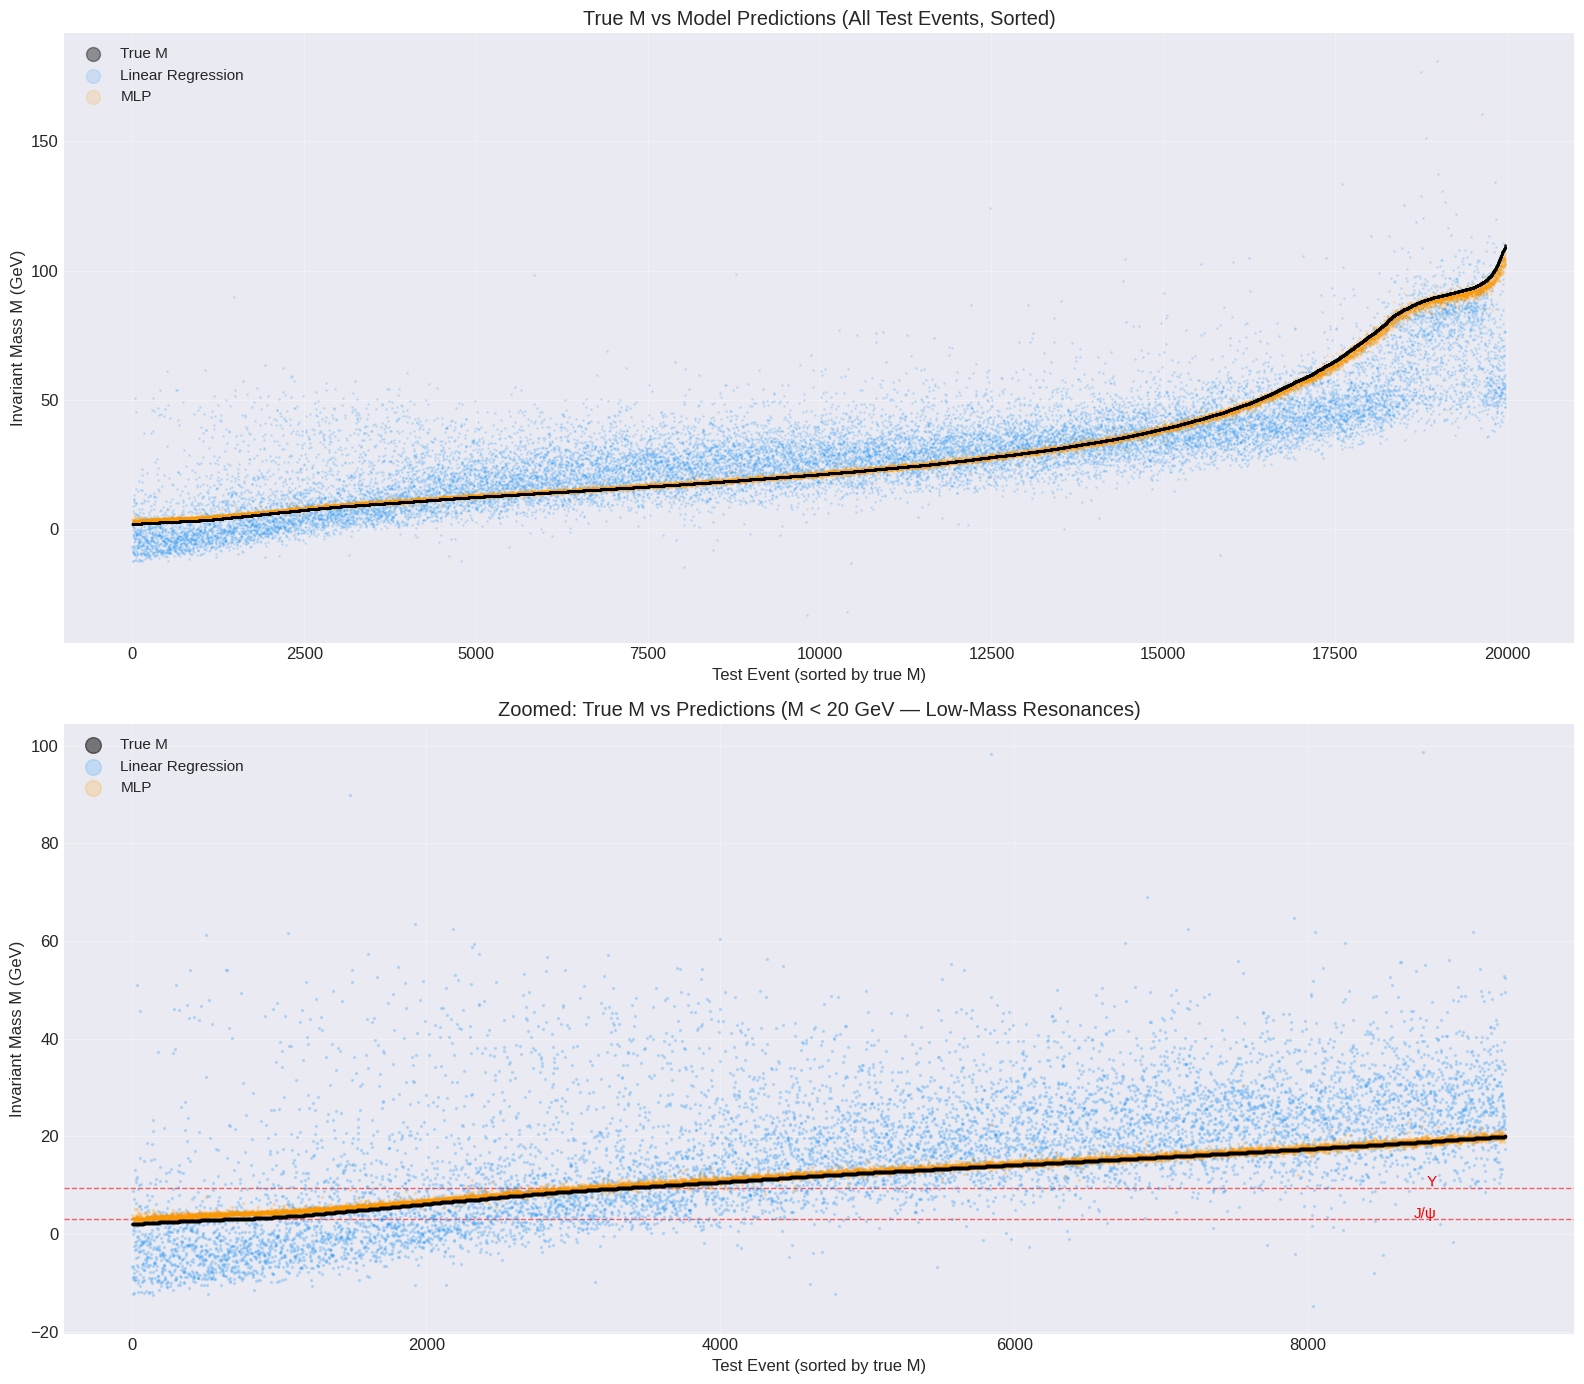

In [ ]:
# Scatter Plot: True M with Model Predictions
# Sort test events by true M for a clean visual
sort_idx = np.argsort(y_test_reg)
x_axis = np.arange(len(y_test_reg))
y_true_sorted = y_test_reg[sort_idx]

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

#Top panel: Full view
ax = axes[0]
ax.scatter(x_axis, y_true_sorted, s=1, alpha=0.4, color='black', label='True M', zorder=5)
for name, y_pred, color, marker in [
    ('Linear Regression', y_pred_lr_full, '#2196F3', '.'),
    ('MLP', y_pred_mlp_full, '#FF9800', '.'),
]:
    y_pred_sorted = y_pred[sort_idx]
    ax.scatter(x_axis, y_pred_sorted, s=1, alpha=0.15, color=color, label=name, zorder=3)

ax.set_xlabel('Test Event (sorted by true M)')
ax.set_ylabel('Invariant Mass M (GeV)')
ax.set_title('True M vs Model Predictions (All Test Events, Sorted)')
ax.legend(markerscale=10, fontsize=11)
ax.grid(True, alpha=0.3)

#Bottom panel: Zoomed into 0–20 GeV (J/ψ + Υ region)
ax2 = axes[1]
mask_zoom = y_true_sorted < 20
x_zoom = x_axis[mask_zoom]

ax2.scatter(x_zoom, y_true_sorted[mask_zoom], s=2, alpha=0.5, color='black', label='True M', zorder=5)
for name, y_pred, color in [
    ('Linear Regression', y_pred_lr_full, '#2196F3'),
    ('MLP', y_pred_mlp_full, '#FF9800'),
]:
    y_pred_sorted = y_pred[sort_idx]
    ax2.scatter(x_zoom, y_pred_sorted[mask_zoom], s=2, alpha=0.2, color=color, label=name, zorder=3)

# Mark resonance peaks
for m_val, lbl in [(3.1, 'J/ψ'), (9.46, 'Υ')]:
    ax2.axhline(m_val, color='red', ls='--', alpha=0.6, lw=1)
    ax2.text(x_zoom[-1]*0.95, m_val+0.3, lbl, fontsize=11, ha='right', color='red')

ax2.set_xlabel('Test Event (sorted by true M)')
ax2.set_ylabel('Invariant Mass M (GeV)')
ax2.set_title('Zoomed: True M vs Predictions (M < 20 GeV — Low-Mass Resonances)')
ax2.legend(markerscale=8, fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


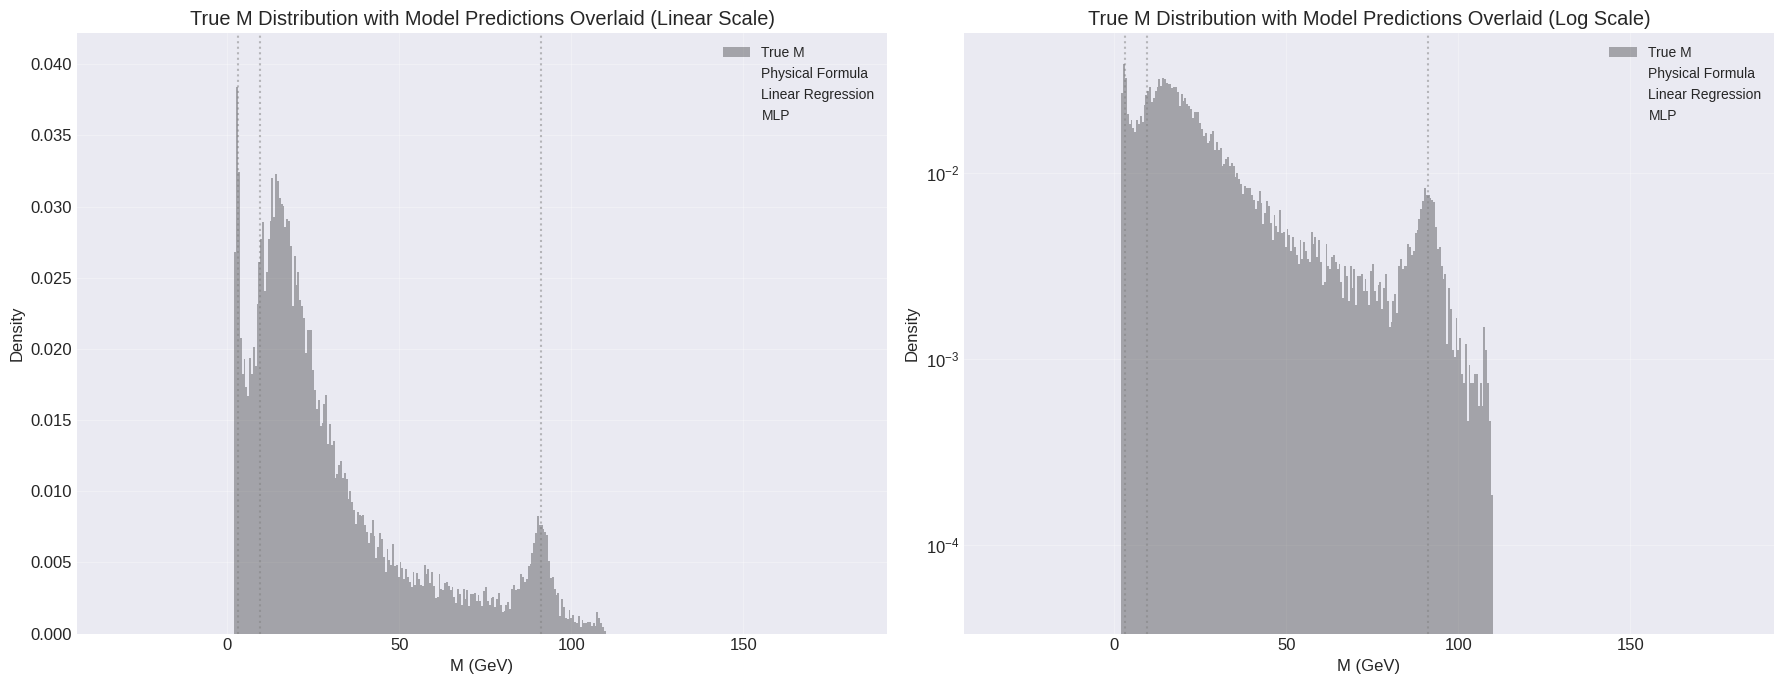


 Models that match the black (true) distribution closely are better at predicting M.


In [ ]:
#  Overlay on True M Distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (yscale, title_suffix) in zip(axes, [('linear', 'Linear Scale'), ('log', 'Log Scale')]):
    # True M histogram
    ax.hist(y_test_reg, bins=200, color='black', alpha=0.3, edgecolor='none',
            label='True M', density=True)

    # Overlay model predictions as histograms
    for name, y_pred, color, ls in [
        ('Physical Formula', M_formula_test, '#9C27B0', '-'),
        ('Linear Regression', y_pred_lr_full, '#2196F3', '--'),
        ('MLP', y_pred_mlp_full, '#FF9800', '-.'),
    ]:
        ax.hist(y_pred, bins=200, color=color, alpha=0.0, edgecolor=color,
                linewidth=1.5, histtype='step', density=True, label=name, linestyle=ls)

    ax.set_xlabel('M (GeV)'); ax.set_ylabel('Density')
    ax.set_title(f'True M Distribution with Model Predictions Overlaid ({title_suffix})')
    ax.set_yscale(yscale)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Mark resonance peaks
    for m_val, lbl in [(3.1, 'J/ψ'), (9.46, 'Υ'), (91.2, 'Z')]:
        ax.axvline(m_val, color='gray', ls=':', alpha=0.5)

plt.tight_layout(); plt.show()
print('\n Models that match the black (true) distribution closely are better at predicting M.')
